# CO2 Emmissions by cars 


## **Project Definition and Goal**<br> 



### Identifying the car technical characteristics that play a role in pollution 

<span style="font-size: 18px">

- This project aims to identify which technical characteristics<br>
of newly registered vehicles most influence their CO₂ emissions.<br>
Our goal is to uncover patterns and predictors of emissions<br>
performance that can inform sustainable vehicle design, <br>
manufacturing strategies, and environmental policy<br>

<br>
    To develop a robust and well-tested approach, we begin<br>
with a focused exploratory analysis using a 2013 dataset<br>
of cars sold in France. Once the analytical pipeline<br>
is validated on this smaller, simpler dataset,<br>
we will apply the same methodology to the<br>
full-scale European Environment Agency (EEA) 2023<br> dataset.
This ensures both efficiency in development and <br>
relevance in our final insights.<br>

## **Datasets Overview**



We'll begin our study with two datasets:

### 1. **France 2013 dataset** (initial EDA phase)

- Contains technical and environmental specifications of passenger cars sold in France in 2013  
- Includes CO₂ emissions, fuel consumption, engine power, mass, and fuel type  
- Used to prototype visualizations, hypothesis tests, and feature selection  

### 2. **EEA 2023 dataset** (main analysis phase)

- Covers all new passenger cars registered in the European Union in 2023  
- Includes updated WLTP-based CO₂ measurements and richer technical data  
- Used to produce the final results and insights relevant to current EU mobility trends  

### Column Glossary: 2013 France Vehicles Dataset

<span style="font-size: 12px">


| **French Column**                                | **English Translation**                   | **Description** |
|--------------------------------------------------|-------------------------------------------|-----------------|
| Marque                                           | `Brand`                                     | Manufacturer of the vehicle (e.g., Renault, BMW). |
| Modèle dossier                                   | `Project_Model`                             | Internal project name used by the manufacturer — <br> less common externally. |
| Modèle UTAC                                      | `UTAC_Model`                                | Model name recognized by UTAC (French vehicle testing <br> authority). |
| Désignation commerciale                          | `Commercial_Name`                           | The marketed model name (e.g., “Clio 4”). |
| CNIT                                             | `CNIT (National Type ID Code)`              | French national Type Identification Code <br> used in registration documents;<br> 12–15 alphanumeric characters. |
| Type Variante Version (TVV)                      | `Type‑Variant‑Version (TVV)`               | Vehicle’s homologation code indicating <br> chassis type, variant, and version. |
| Carburant                                        | `Fuel_Type `                                | The type of fuel used (e.g., gasoline, diesel, electric). |
| Hybride                                          | `Hybrid`                                    | Indicates if the vehicle is hybrid (yes/no or binary indicator). |
| Puissance administrative                         | `Fiscal_Power(CV)`                         | A taxation metric used in France, not actual engine power. |
| Puissance maximale (kW)                          | `Max_Power(kW)`                             | Actual engine power output in kilowatts. |
| Boîte de vitesse                                 | `Gearbox`                                   | Transmission type (manual, automatic, CVT, etc.). |
| Consommation urbaine (l/100km)                   | `Urban_Consumption(L/100km)`                | Fuel consumption in city driving. |
| Consommation extra-urbaine (l/100km)             | `Extra‑urban_Consumption(L/100km)`          | Fuel consumption on highways. |
| Consommation mixte (l/100km)                     | `Combined_Consumption(L/100km)`             | Overall fuel consumption combining urban and highway. |
| CO2 (g/km)                                       | `CO2_Emissions(g/km)`                       | Carbon dioxide emissions per kilometer. |
| CO type I (g/km)                                 | `CO_Type_I(g/km)`                           | Carbon monoxide emissions (test cycle I). |
| HC (g/km)                                        | `Hydrocarbons(g/km)`                        | Hydrocarbon emissions per kilometer. |
| NOX (g/km)                                       | `Nitrogen Oxides(g/km)`                     | NOx emissions per kilometer. |
| HC+NOX (g/km)                                    | `HC + NOx(g/km)`                            | Combined hydrocarbon and nitrogen oxide emissions. |
| Particules (g/km)                                | `Particles(g/km)`                           | Particulate matter emissions (e.g., soot). |
| masse vide euro min (kg)                         | `Unladen_Mass_Euro_Min(kg)`                 | Minimum curb weight under Euro standards. |
| masse vide euro max (kg)                         | `Unladen_Mass_Euro_Max(kg)`                 | Maximum curb weight under Euro standards. |
| Champ V9                                         | `Field_V9`                                  | Unknown – no standard meaning found. |
| Date de mise à jour                              | `Update_Date`                               | Last update of the record. |
| Carrosserie                                      | `Body_Type`                                 | Vehicle body style (e.g., sedan, SUV, hatchback). |
| gamme                                            | `Segment/Range`                             | Vehicle category (e.g., compact, luxury). |

## **Data Loading**

In [2]:
### importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# 2013 France Database into df 
df = pd.read_csv('../data/raw/2013_car_data.csv', sep=';', encoding='latin1')


## **Data Exploration of France Data Set**

### Data Information

<span style="font-size: 16px">

#### 2013 France Data Frame 1st Exploration

In [4]:
#df infos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44850 entries, 0 to 44849
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Marque                                44850 non-null  object 
 1   Modèle dossier                        44850 non-null  object 
 2   Modèle UTAC                           44850 non-null  object 
 3   Désignation commerciale               44850 non-null  object 
 4   CNIT                                  44850 non-null  object 
 5   Type Variante Version (TVV)           44850 non-null  object 
 6   Carburant                             44850 non-null  object 
 7   Hybride                               44850 non-null  object 
 8   Puissance administrative              44850 non-null  int64  
 9   Puissance maximale (kW)               44850 non-null  float64
 10  Boîte de vitesse                      44850 non-null  object 
 11  Consommation ur

In [5]:
display(df.head())

df.tail()

,Marque,Modèle dossier,Modèle UTAC,Désignation commerciale,CNIT,Type Variante Version (TVV),Carburant,Hybride,Puissance administrative,Puissance maximale (kW),...,HC (g/km),NOX (g/km),HC+NOX (g/km),Particules (g/km),masse vide euro min (kg),masse vide euro max (kg),Champ V9,Date de mise à jour,Carrosserie,gamme
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147.0,...,0.052,0.032,NaN,0.002,1505,1505,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
1,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9,125.0,...,NaN,0.169,0.190,0.003,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100.0,...,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100.0,...,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125.0,...,NaN,0.164,0.193,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER


,Marque,Modèle dossier,Modèle UTAC,Désignation commerciale,CNIT,Type Variante Version (TVV),Carburant,Hybride,Puissance administrative,Puissance maximale (kW),...,HC (g/km),NOX (g/km),HC+NOX (g/km),Particules (g/km),masse vide euro min (kg),masse vide euro max (kg),Champ V9,Date de mise à jour,Carrosserie,gamme
44845,VOLVO,XC70,XC70,XC70 D4 (163ch) AWD Geartronic 6,M10VLVVP874P723,BZ8756,GO,non,10,120.0,...,NaN,0.116,0.152,0.000,1799,1799,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44846,VOLVO,XC70,XC70,XC70 D4 (163ch) Stop&Start AWD BVM6,M10VLVVP8725584,BZ87A4,GO,non,9,120.0,...,NaN,0.106,0.144,0.000,1786,1786,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44847,VOLVO,XC70,XC70,XC70 D4 (163ch) Geartronic 6,M10VLVVP8726585,BZ8850,GO,non,9,120.0,...,NaN,0.108,0.132,0.001,1726,1726,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44848,VOLVO,XC70,XC70,XC70 D4 (163ch) Stop&Start BVM6,M10VLVVP8727586,BZ88A1,GO,non,9,120.0,...,NaN,0.127,0.152,0.001,1706,1706,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44849,VOLVO,XC70,XC70,XC70 T6 (304ch) AWD Geartronic 6,M10VLVVP874P724,BZ90H6,ES,non,21,224.0,...,0.038,0.027,NaN,NaN,1815,1815,715/2007*566/2011EURO5,juin-13,BREAK,SUPERIEURE


### Data Translation

In [6]:
translations = {
    'Marque': 'Brand',
    'Modèle dossier': 'Project_Model',
    'Modèle UTAC': 'UTAC_Model',
    'Désignation commerciale': 'Commercial_Name',
    'CNIT': 'CNIT',
    'Type Variante Version (TVV)': 'TVV',
    'Carburant': 'Fuel_Type',
    'Hybride': 'Hybrid',
    'Puissance administrative': 'Fiscal_Power',
    'Puissance maximale (kW)': 'Max_Power(kW)',
    'Boîte de vitesse': 'Gearbox',
    'Consommation urbaine (l/100km)': 'Urban_Consumption(L/100km)',
    'Consommation extra-urbaine (l/100km)': 'Extra-urban_Consumption(L/100km)',
    'Consommation mixte (l/100km)': 'Combined_Consumption(L/100km)',
    'CO2 (g/km)': 'CO2(g/km)',
    'CO type I (g/km)': 'CO_Type_I(g/km)',
    'HC (g/km)': 'HC(g/km)',
    'NOX (g/km)': 'NOX(g/km)',
    'HC+NOX (g/km)': 'HC+NOX(g/km)',
    'Particules (g/km)': 'Particles(g/km)',
    'masse vide euro min (kg)': 'Unladen_Mass_Min(kg)',
    'masse vide euro max (kg)': 'Unladen_Mass_Max(kg)',
    'Champ V9': 'Field_V9',
    'Date de mise à jour': 'Update_Date',
    'Carrosserie': 'Body_Type',
    'gamme': 'Segment'
}

In [7]:
df.rename(columns=translations, inplace=True)


In [8]:
df.columns

Index(['Brand', 'Project_Model', 'UTAC_Model', 'Commercial_Name', 'CNIT',
       'TVV', 'Fuel_Type', 'Hybrid', 'Fiscal_Power', 'Max_Power(kW)',
       'Gearbox', 'Urban_Consumption(L/100km)',
       'Extra-urban_Consumption(L/100km)', 'Combined_Consumption(L/100km)',
       'CO2(g/km)', 'CO_Type_I(g/km)', 'HC(g/km)', 'NOX(g/km)', 'HC+NOX(g/km)',
       'Particles(g/km)', 'Unladen_Mass_Min(kg)', 'Unladen_Mass_Max(kg)',
       'Field_V9', 'Update_Date', 'Body_Type', 'Segment'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44850 entries, 0 to 44849
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Brand                             44850 non-null  object 
 1   Project_Model                     44850 non-null  object 
 2   UTAC_Model                        44850 non-null  object 
 3   Commercial_Name                   44850 non-null  object 
 4   CNIT                              44850 non-null  object 
 5   TVV                               44850 non-null  object 
 6   Fuel_Type                         44850 non-null  object 
 7   Hybrid                            44850 non-null  object 
 8   Fiscal_Power                      44850 non-null  int64  
 9   Max_Power(kW)                     44850 non-null  float64
 10  Gearbox                           44850 non-null  object 
 11  Urban_Consumption(L/100km)        44808 non-null  float64
 12  Extr

In [10]:
df['Gearbox'].value_counts()

Gearbox
M 6    19364
A 5    13770
A 7     8428
M 5     1425
A 6     1101
A 8      446
V 0      180
A 4       39
D 5       39
D 7       21
M 7       12
D 6       11
A 0       10
N 1        2
S 6        1
N 0        1
Name: count, dtype: int64

In [11]:
display(df['Fiscal_Power'].unique())

array([12,  9,  7, 38, 14,  5,  8,  6,  4, 44, 80, 81, 49, 51, 34, 35, 45,
       33, 10, 16, 19, 15, 23, 11, 18, 22, 17, 31, 20, 47, 21, 24, 41, 42,
       13, 48, 25, 57, 26, 46, 32, 27, 50, 43, 60,  3,  1, 40, 72, 73, 63,
       62, 30, 29, 39, 68, 28, 37, 58, 36, 56, 52])

In [12]:
df['Fiscal_Power'] = df['Fiscal_Power'].astype("float") 

df['Unladen_Mass_Min(kg)'] = df['Unladen_Mass_Min(kg)'].astype("float") 

df['Unladen_Mass_Max(kg)'] = df['Unladen_Mass_Max(kg)'].astype("float")


In [13]:
# Null values and their percentage in each column

df_info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Null Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
print(df_info.to_string(index=False))

                          Column Data Type  Non-Null Count  Null Count  Null Percentage
                           Brand    object           44850           0             0.00
                   Project_Model    object           44850           0             0.00
                      UTAC_Model    object           44850           0             0.00
                 Commercial_Name    object           44850           0             0.00
                            CNIT    object           44850           0             0.00
                             TVV    object           44850           0             0.00
                       Fuel_Type    object           44850           0             0.00
                          Hybrid    object           44850           0             0.00
                    Fiscal_Power   float64           44850           0             0.00
                   Max_Power(kW)   float64           44850           0             0.00
                         Gearbox

Based on the Null Percentage it is clear that HC cannot be used and must be dropped. 
HC+NOX should be investigated further, maybe some imputing techniques could be used.

In [14]:
# Duplicates in the DataFrame and their percentage

duplicates_count = df.duplicated().sum()
duplicates_percentage = (duplicates_count / len(df) * 100).round(2)
print(f"Number of duplicates: {duplicates_count} ({duplicates_percentage}%)")

Number of duplicates: 619 (1.38%)


Duplicates should be dropped in the next steps

In [15]:
df.describe()

,Fiscal_Power,Max_Power(kW),Urban_Consumption(L/100km),Extra-urban_Consumption(L/100km),Combined_Consumption(L/100km),CO2(g/km),CO_Type_I(g/km),HC(g/km),NOX(g/km),HC+NOX(g/km),Particles(g/km),Unladen_Mass_Min(kg),Unladen_Mass_Max(kg)
count,44850.000000,44850.000000,44808.000000,44808.000000,44811.000000,44811.000000,44547.000000,10403.000000,44547.000000,34191.000000,41708.000000,44850.000000,44850.000000
mean,11.018997,124.780834,9.706744,6.567634,7.716254,198.910892,0.153461,0.030499,0.311837,0.224788,0.000961,2070.961650,2169.545284
std,5.554475,49.158804,2.366181,1.196234,1.597110,39.014678,0.138984,0.018408,0.463112,0.041681,0.006469,342.872975,410.600541
min,1.000000,10.000000,0.000000,2.800000,1.200000,27.000000,0.005000,0.008000,0.001000,0.038000,0.000000,825.000000,825.000000
25%,9.000000,100.000000,8.800000,6.300000,7.200000,187.000000,0.046000,0.008000,0.158000,0.201000,0.000000,1976.000000,2043.500000
50%,10.000000,120.000000,9.800000,6.700000,7.700000,203.000000,0.093000,0.031000,0.197000,0.220000,0.001000,2076.000000,2185.000000
75%,11.000000,125.000000,10.700000,7.100000,8.400000,221.000000,0.222000,0.044000,0.228000,0.248000,0.001000,2256.000000,2355.000000
max,81.000000,559.300000,41.100000,14.900000,24.500000,572.000000,0.968000,0.143000,1.846000,0.306000,0.610000,3115.000000,3115.000000


In [16]:
categorical_columns = df.select_dtypes(include=['object']).columns
print(f"Categorical columns found: {list(categorical_columns)}")

for col in categorical_columns:
    unique_count = df[col].nunique()
    print(f"\n{col}:")
    print(f"  - Unique values: {unique_count}")
    
    # Get value counts and percentages
    value_counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    
    if unique_count <= 10:
        print(f"  - All values with distribution:")
        display_data = list(zip(value_counts.index, value_counts.values, percentages.values))
    else:
        print(f"  - Top 10 values with distribution:")
        display_data = list(zip(value_counts.head(10).index, value_counts.head(10).values, percentages.head(10).values))
    
    for val, count, pct in display_data:
        print(f"    {val}: {count} ({pct:.1f}%)")

Categorical columns found: ['Brand', 'Project_Model', 'UTAC_Model', 'Commercial_Name', 'CNIT', 'TVV', 'Fuel_Type', 'Hybrid', 'Gearbox', 'Field_V9', 'Update_Date', 'Body_Type', 'Segment']

Brand:
  - Unique values: 51
  - Top 10 values with distribution:
    MERCEDES-BENZ: 38450 (85.7%)
    VOLKSWAGEN: 900 (2.0%)
    FIAT: 607 (1.4%)
    OPEL: 586 (1.3%)
    BMW: 525 (1.2%)
    SKODA: 364 (0.8%)
    FORD: 296 (0.7%)
    AUDI: 242 (0.5%)
    CITROEN: 207 (0.5%)
    MAZDA: 193 (0.4%)

Project_Model:
  - Unique values: 458
  - Top 10 values with distribution:
    VIANO: 14031 (31.3%)
    VITO: 9890 (22.1%)
    SPRINTER: 8323 (18.6%)
    CLASSE E: 2849 (6.4%)
    CLASSE C: 1302 (2.9%)
    CADDY: 657 (1.5%)
    CLASSE B: 434 (1.0%)
    CLASSE S: 336 (0.7%)
    CLASSE M: 277 (0.6%)
    CLASSE A: 255 (0.6%)

UTAC_Model:
  - Unique values: 419
  - Top 10 values with distribution:
    VIANO: 14031 (31.3%)
    VITO: 9890 (22.1%)
    SPRINTER: 8323 (18.6%)
    E 250: 674 (1.5%)
    E 200: 670 (1.5

In [17]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

df_Viano2= df[df['Commercial_Name'] == 'VIANO 2.2 CDI']

df_Viano2.head(10)


,Brand,Project_Model,UTAC_Model,Commercial_Name,CNIT,TVV,Fuel_Type,Hybrid,Fiscal_Power,Max_Power(kW),Gearbox,Urban_Consumption(L/100km),Extra-urban_Consumption(L/100km),Combined_Consumption(L/100km),CO2(g/km),CO_Type_I(g/km),HC(g/km),NOX(g/km),HC+NOX(g/km),Particles(g/km),Unladen_Mass_Min(kg),Unladen_Mass_Max(kg),Field_V9,Update_Date,Body_Type,Segment
17883,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP0229928,639/2LAA31280N1A2B2S27,GO,non,10.0,120.0,A 5,10.0,6.8,8.0,211.0,0.078,NaN,0.224,0.233,0.001,2025.0,2075.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17884,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022A929,639/2LAA31280N1A2B2S28,GO,non,10.0,120.0,A 5,10.0,6.8,8.0,211.0,0.078,NaN,0.224,0.233,0.001,2025.0,2075.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17885,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022B930,639/2LAA31280N1A2B2S37,GO,non,10.0,120.0,A 5,10.0,6.8,8.0,211.0,0.078,NaN,0.224,0.233,0.001,2025.0,2075.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17886,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022C931,639/2LAA31280N1A2B2S38,GO,non,10.0,120.0,A 5,10.0,6.8,8.0,211.0,0.078,NaN,0.224,0.233,0.001,2025.0,2075.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17887,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022D932,639/2LAA31280N1A2B2T27,GO,non,11.0,120.0,A 5,10.1,6.9,8.1,213.0,0.078,NaN,0.224,0.233,0.001,2076.0,2185.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17888,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022E933,639/2LAA31280N1A2B2T28,GO,non,11.0,120.0,A 5,10.1,6.9,8.1,213.0,0.078,NaN,0.224,0.233,0.001,2076.0,2185.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17889,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022F934,639/2LAA31280N1A2B2T37,GO,non,11.0,120.0,A 5,10.1,6.9,8.1,213.0,0.078,NaN,0.224,0.233,0.001,2076.0,2185.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17890,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022G935,639/2LAA31280N1A2B2T38,GO,non,11.0,120.0,A 5,10.1,6.9,8.1,213.0,0.078,NaN,0.224,0.233,0.001,2076.0,2185.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17891,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022H936,639/2LAA31280N1A2B2U27,GO,non,11.0,120.0,A 5,10.2,7.0,8.2,216.0,0.078,NaN,0.224,0.233,0.001,2186.0,2350.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17892,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022J937,639/2LAA31280N1A2B2U28,GO,non,11.0,120.0,A 5,10.2,7.0,8.2,216.0,0.078,NaN,0.224,0.233,0.001,2186.0,2275.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER


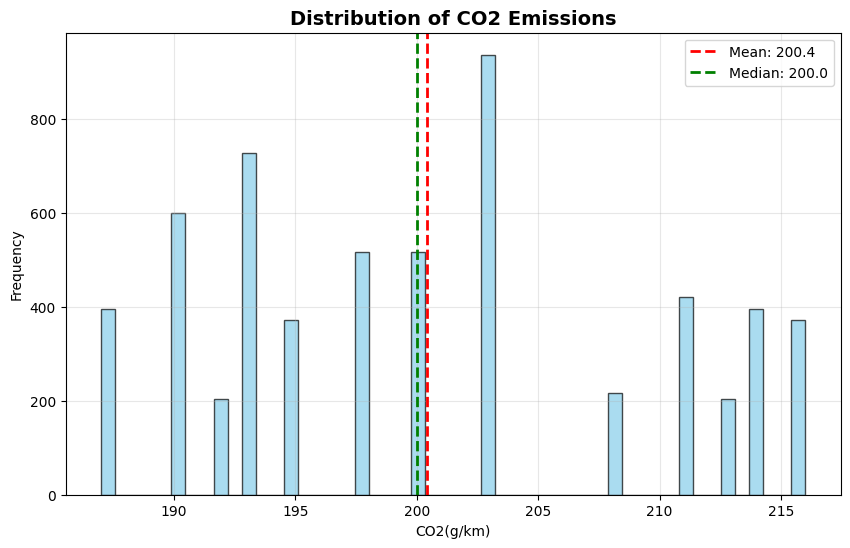

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(df_Viano2['CO2(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(df_Viano2['CO2(g/km)'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df_Viano2["CO2(g/km)"].mean():.1f}')
plt.axvline(df_Viano2['CO2(g/km)'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {df_Viano2["CO2(g/km)"].median():.1f}')
plt.title('Distribution of CO2 Emissions', fontsize=14, fontweight='bold')
plt.xlabel('CO2(g/km)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### General Overview and Distribution of Data Variables


- The dataset is imbalanced with respect to <span style="color:red">Brand & Model </span> attributes, being heavily dominated by specific values.
    - 85.7% of the dataset consists of Mercedes vehicles
    - 72% of the dataset comprises the following 3 Mercedes models:
        - VIANO: 14031 (31.3%)
        - VITO: 9890 (22.1%)
        - SPRINTER: 8323 (18.6%)

- They look very similar to eachother The records listed under similar <span style="color:red">Commercial names</span> require further investigation to determine their distinctions, as they appear to be quite similar:
    - VIANO 2.2 CDI: 5874 (13.1%)
    - VIANO 2.0 CDI: 3903 (8.7%)
    - COMBI 116 CDI: 3754 (8.4%)
    - COMBI 113 CDI: 2620 (5.8%)
    - VIANO 3.0 CDI: 1608 (3.6%)



- Can we clarify or translate the <span style="color:red">Gearbox</span> attribute values? Specifically
    - What do the respective codes represent? For example, Is M6 equivalent to "Manual 6-speed"?
- Current distribution:
    - M 6: 19364 (43.2%)
    - A 5: 13770 (30.7%)
    - A 7: 8428 (18.8%)

- How should we interpret <span style="color:red">Field_V9</span> attribute as the top 3 values are covering 80.2% of the dataset? Can we deduct something from the respective values?
   - 715/2007*692/2008EURO5: 26426 (59.2%)
   - 715/2007*566/2011EURO5: 8250 (18.5%)
   - 715/2007*630/2012EURO5: 3332 (7.5%)

## Ideas

Similar Brand+Models (mostly Mercedes ones) could be removed to balance the dataset to simplify and bring balance to the dataset. It should be investigated further.

## TARGET VARIABLE ANALYSIS: CO2 (g/km)

In [19]:
### TARGET VARIABLE ANALYSIS: CO2 (g/km)

display(df['CO2(g/km)'].describe())

count    44811.000000
mean       198.910892
std         39.014678
min         27.000000
25%        187.000000
50%        203.000000
75%        221.000000
max        572.000000
Name: CO2(g/km), dtype: float64

Text(0.5, 1.0, 'Q-Q Plot (Normality Check)')

/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


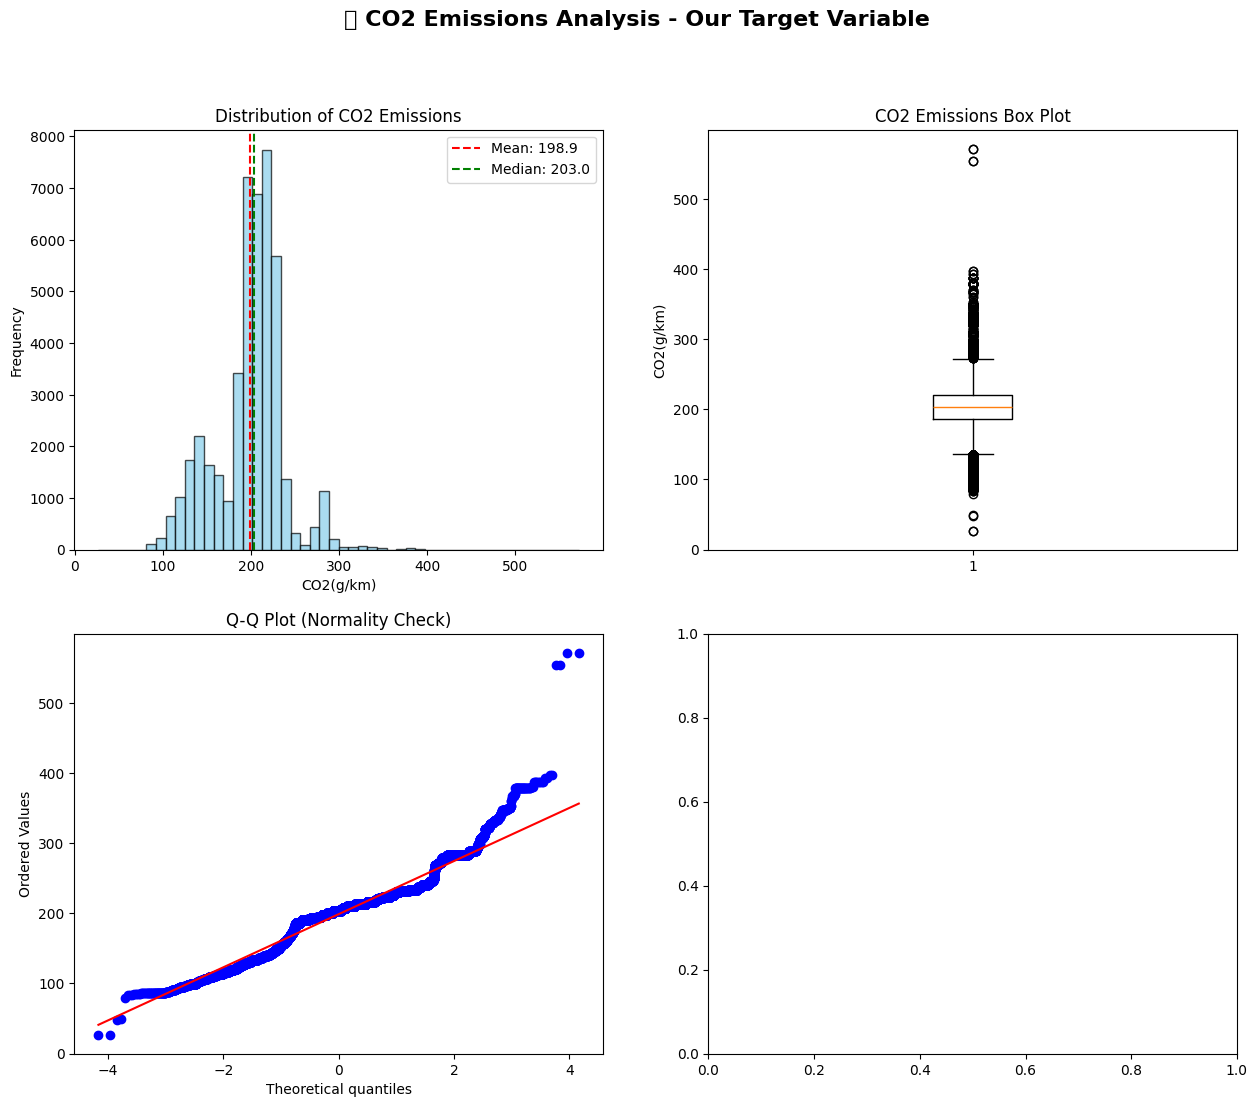

In [65]:
# Create comprehensive CO2 analysis plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 CO2 Emissions Analysis - Our Target Variable', fontsize=16, fontweight='bold')

# Distribution histogram
axes[0,0].hist(df['CO2(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df['CO2(g/km)'].mean(), color='red', linestyle='--', label=f'Mean: {df["CO2(g/km)"].mean():.1f}')
axes[0,0].axvline(df['CO2(g/km)'].median(), color='green', linestyle='--', label=f'Median: {df["CO2(g/km)"].median():.1f}')
axes[0,0].set_title('Distribution of CO2 Emissions')
axes[0,0].set_xlabel('CO2(g/km)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Box plot
axes[0,1].boxplot(df['CO2(g/km)'].dropna())
axes[0,1].set_title('CO2 Emissions Box Plot')
axes[0,1].set_ylabel('CO2(g/km)')

# Q-Q plot for normality
stats.probplot(df['CO2(g/km)'].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Normality Check)')



Q-Q PLOT: The data follows a normal distribution so it is approximately normal enough for most statistical analyses.

Those consumptions above 400 are real and not outliers.

## **Correlation between variables**

### Correlation matrix

In [21]:
df_num = df.select_dtypes(include='number').corr()

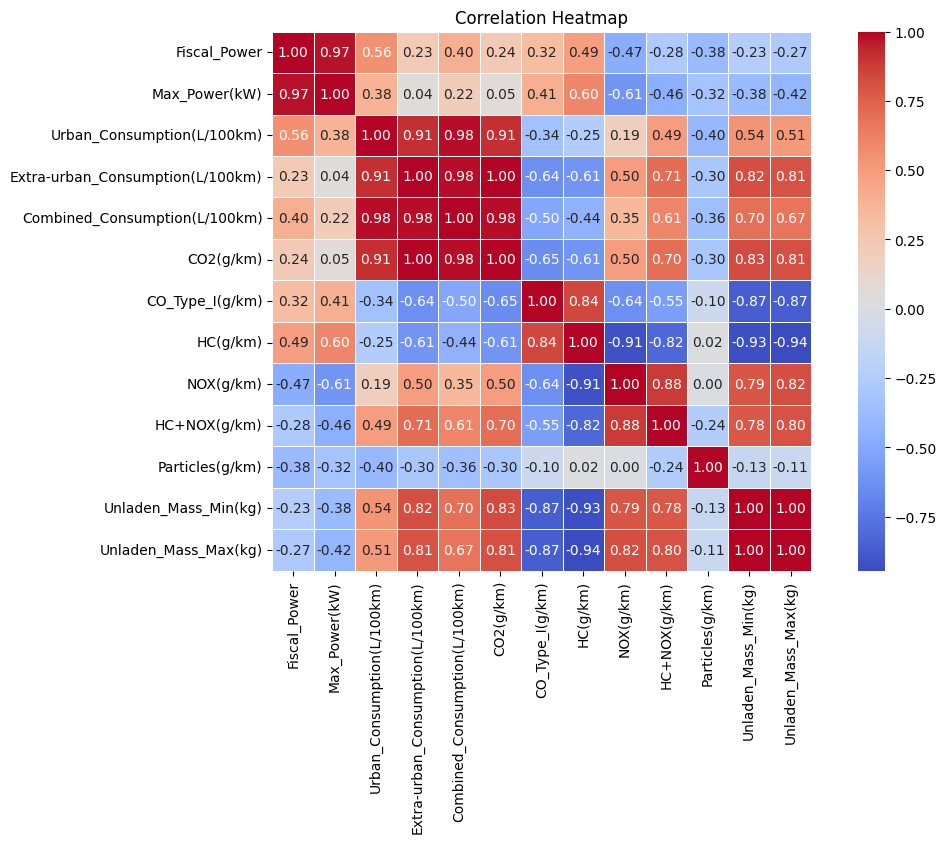

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
df_corr_matrix = df_num.corr()


sns.heatmap(df_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

### <span style="color:red">The correlation above should be discarded </span>

The issue in your the is that we are applying .corr() twice, which is causing the problem:
df_num = df.select_dtypes(include='number').corr()
df_corr_matrix = df_num.corr()

The CO2 seems to be: <br> 
- high positiv correlated with the Car Maximum Mass and <br>
"HC + NOX" 
- negatively correlated with CO Type I and HC. <br>
ATTENTION: It's a bit strange that these last two are negatively correlated with CO2. 

Correlation with CO2 emissions:
CO2(g/km)                           1.000000
Extra-urban_Consumption(L/100km)    0.970792
Combined_Consumption(L/100km)       0.959571
Urban_Consumption(L/100km)          0.907357
Unladen_Mass_Min(kg)                0.695331
Unladen_Mass_Max(kg)                0.685936
HC+NOX(g/km)                        0.673189
Fiscal_Power                        0.480768
Max_Power(kW)                       0.361228
NOX(g/km)                           0.264285
Particles(g/km)                     0.053874
CO_Type_I(g/km)                    -0.132099
HC(g/km)                           -0.326438
Name: CO2(g/km), dtype: float64


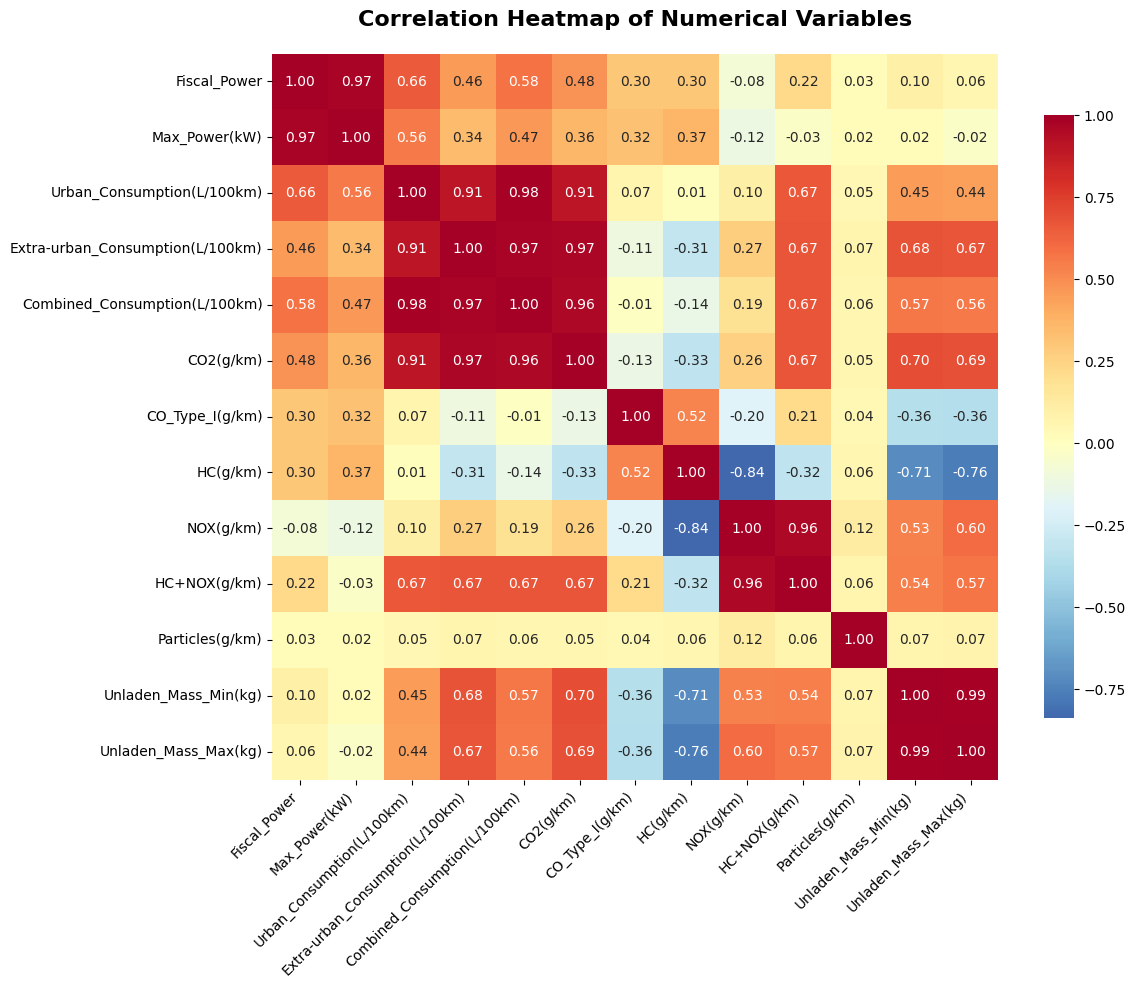

In [23]:
#key_numerical = ['Fiscal_Power', 'Max_Power(kW)', 'Urban_Consumption(L/100km)', 'Extra-urban_Consumption(L/100km)','Combined_Consumption(L/100km)', 'CO_Type_I',
                # 'HC(g/km)', 'NOX(g/km)', 'HC+NOX(g/km)', 'Particles(g/km)', 'Unladen_Mass_Min(kg)', 'Unladen_Mass_Max(kg)']
numerical_cols = df.select_dtypes(include=[np.number]).columns

#display(numerical_cols)
corr_with_co2 = df[numerical_cols].corr()['CO2(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
print(corr_with_co2)

# Create correlation matrix for all numerical columns
correlation_matrix = df[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='RdYlBu_r',      # Color scheme (red-yellow-blue reversed)
            center=0,             # Center colormap at 0
            square=True,          # Make cells square-shaped
            fmt='.2f',            # Format numbers to 2 decimal places
            cbar_kws={'shrink': 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation with CO2 emissions:
CO2(g/km)                           1.000000
Extra-urban_Consumption(L/100km)    0.970792
Combined_Consumption(L/100km)       0.959571
Urban_Consumption(L/100km)          0.907357
Unladen_Mass_Min(kg)                0.695331
Unladen_Mass_Max(kg)                0.685936
HC+NOX(g/km)                        0.673189
Fiscal_Power                        0.480768
Max_Power(kW)                       0.361228
NOX(g/km)                           0.264285
Particles(g/km)                     0.053874
CO_Type_I(g/km)                    -0.132099
HC(g/km)                           -0.326438
Name: CO2(g/km), dtype: float64


/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_65232/3150502464.py:43: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


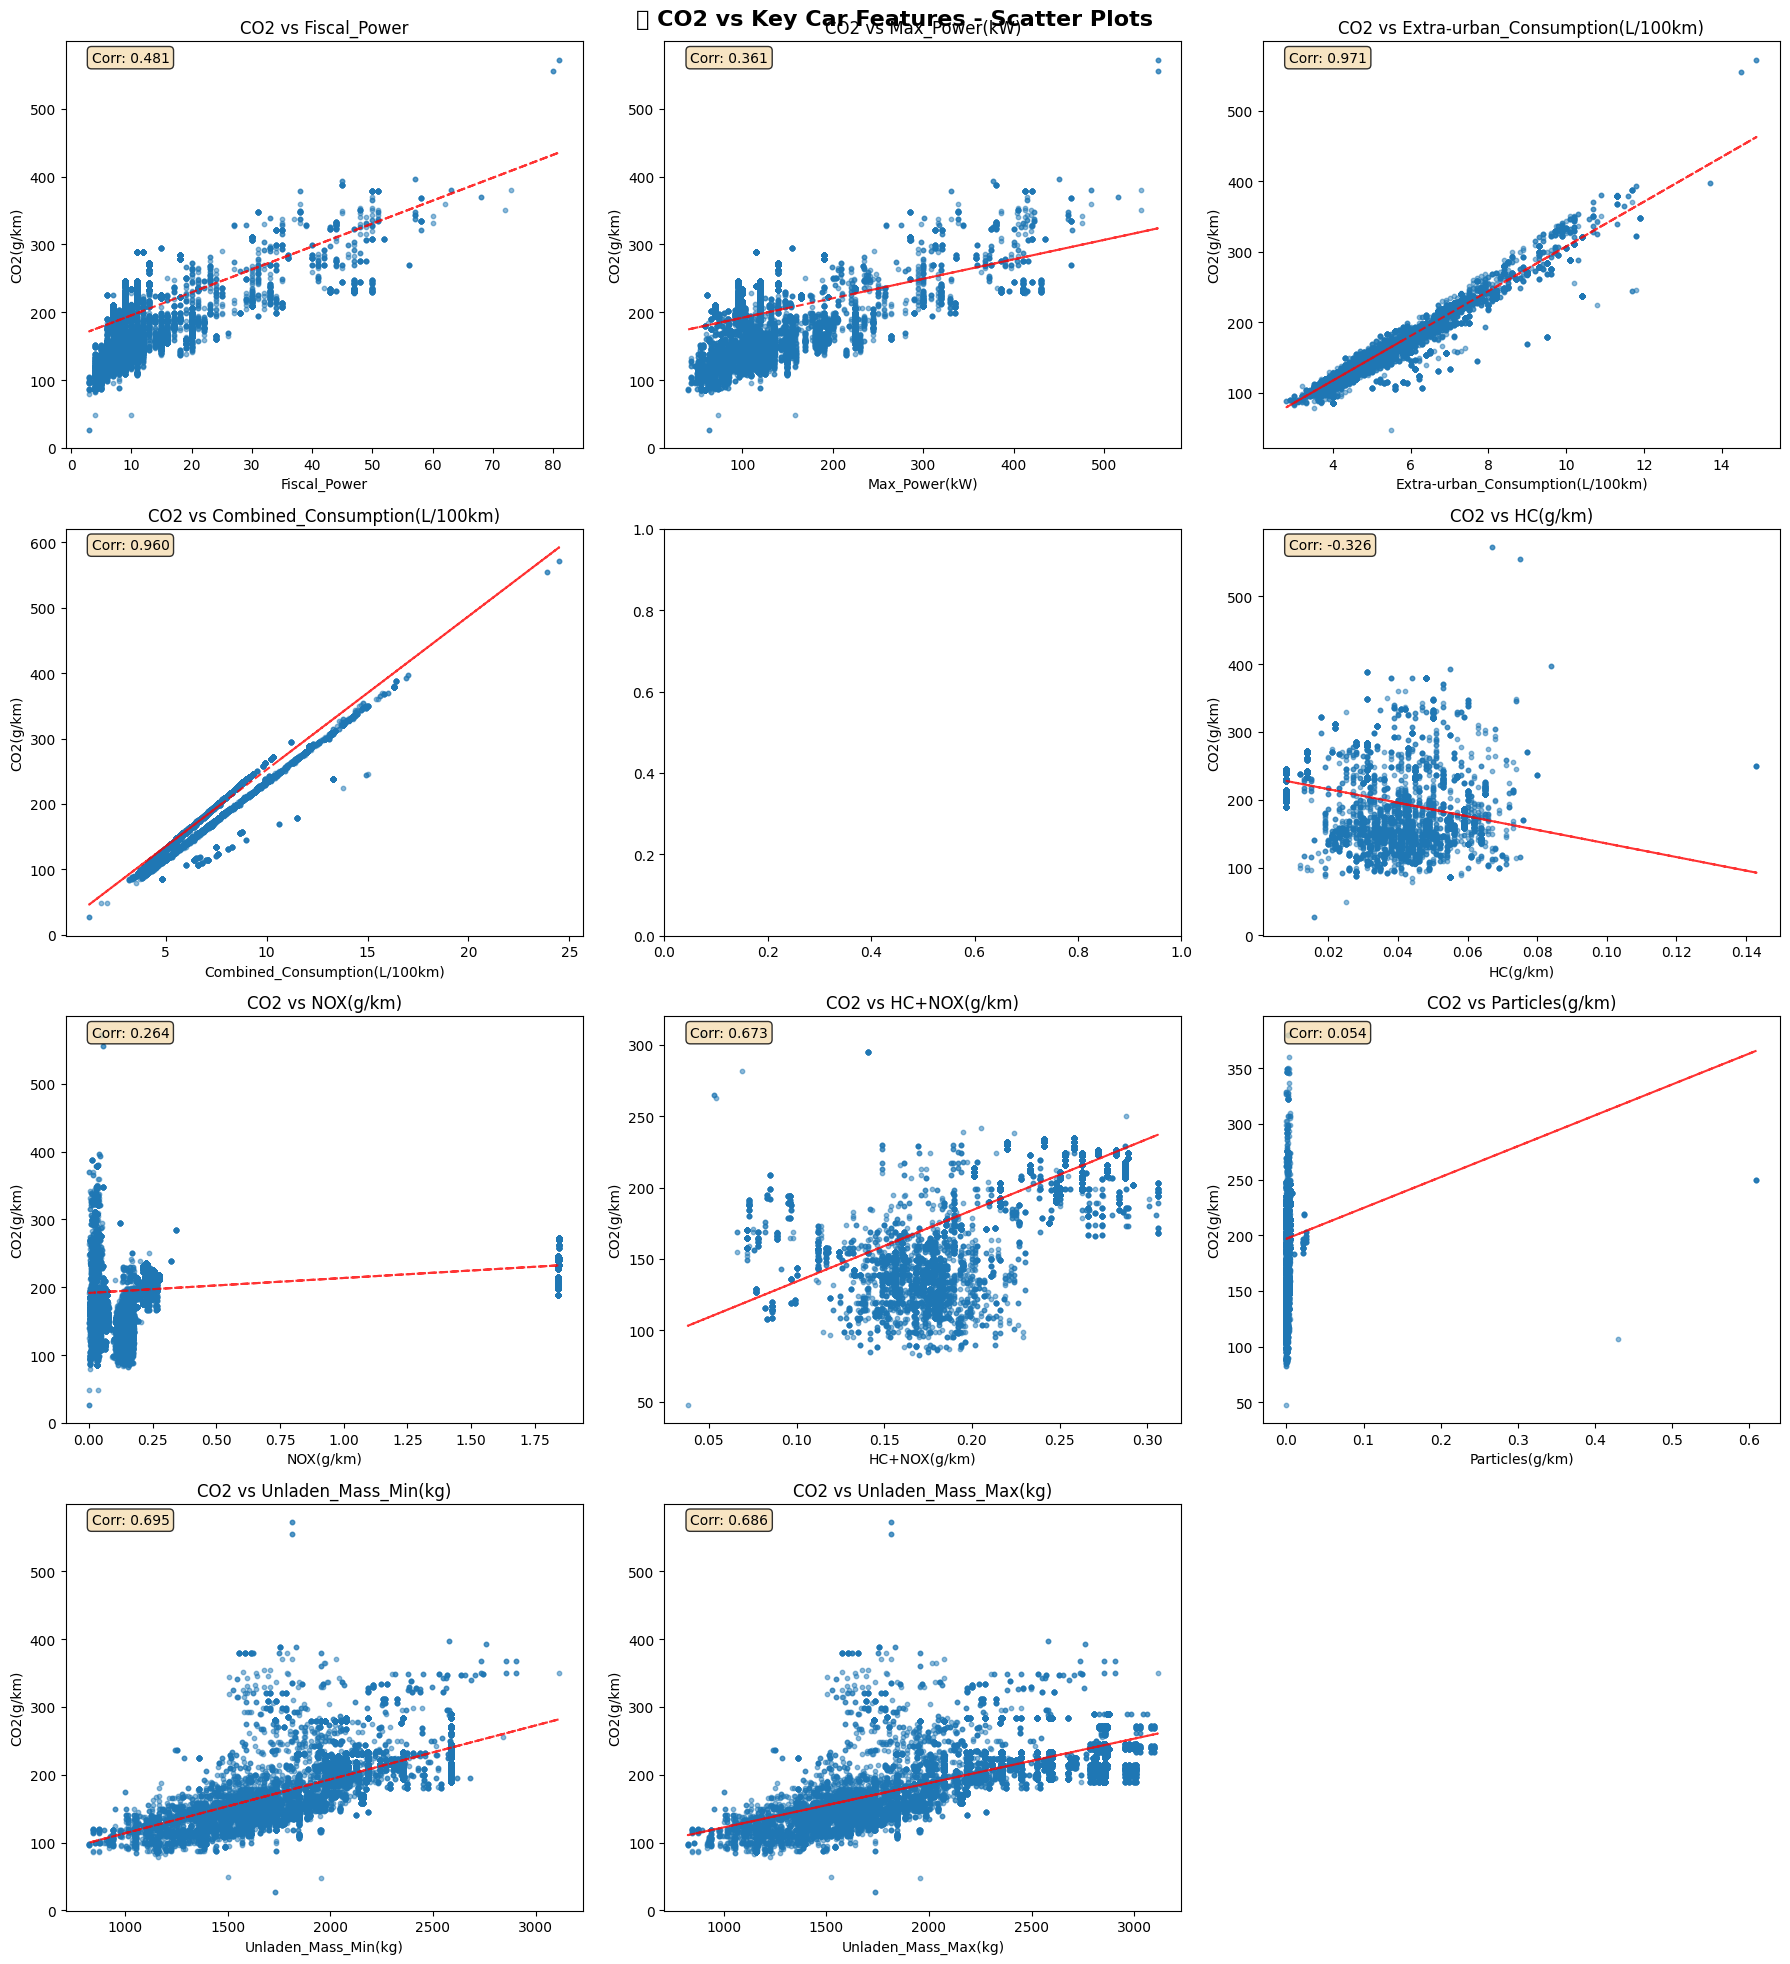

In [24]:
# KEY RELATIONSHIPS: CO2 vs NUMERICAL FEATURES

key_numerical = ['Fiscal_Power', 'Max_Power(kW)', 'Extra-urban_Consumption(L/100km)','Combined_Consumption(L/100km)', 'CO_Type_I',
                 'HC(g/km)', 'NOX(g/km)', 'HC+NOX(g/km)', 'Particles(g/km)', 'Unladen_Mass_Min(kg)', 'Unladen_Mass_Max(kg)']
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_with_co2 = df[numerical_cols].corr()['CO2(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
print(corr_with_co2)

import math

# Scatter plots for key relationships
n_features = len(key_numerical)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
fig.suptitle('🔍 CO2 vs Key Car Features - Scatter Plots', fontsize=16, fontweight='bold')

# Flatten axes for easy indexing
axes = axes.flatten() if n_features > 1 else [axes]

for i, feature in enumerate(key_numerical):
    if feature in df.columns:
        clean_data = df[[feature, 'CO2(g/km)']].dropna()
        axes[i].scatter(clean_data[feature], clean_data['CO2(g/km)'], alpha=0.5, s=10)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('CO2(g/km)')
        axes[i].set_title(f'CO2 vs {feature}')
        # Add trend line
        if len(clean_data) > 1:
            z = np.polyfit(clean_data[feature], clean_data['CO2(g/km)'], 1)
            p = np.poly1d(z)
            axes[i].plot(clean_data[feature], p(clean_data[feature]), "r--", alpha=0.8)
        # Add correlation coefficient
        corr = clean_data[feature].corr(clean_data['CO2(g/km)'])
        axes[i].text(0.05, 0.95, f'Corr: {corr:.3f}', transform=axes[i].transAxes, 
                     bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

# Remove unused subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Multicolinearity
There are some variables that show Multicolinearity, we could look for them with a variance inflation factor

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


## Critical Error

vif["Variable"] = df_num.columns 

here df_num is defined as df_num = df.select_dtypes(include='number').corr() . Correlation part is mixing the values

In [26]:
# VIF calculation
vif = pd.DataFrame()
vif["Variable"] = df_num.columns
vif["VIF"] = [variance_inflation_factor(df_num.values, i) for i in range(df_num.shape[1])]

print(vif)

                            Variable           VIF
0                       Fiscal_Power  2.247420e+04
1                      Max_Power(kW)  1.751192e+04
2         Urban_Consumption(L/100km)  3.173689e+06
3   Extra-urban_Consumption(L/100km)  2.149112e+06
4      Combined_Consumption(L/100km)  1.079079e+07
5                          CO2(g/km)  2.347924e+04
6                    CO_Type_I(g/km)  9.487487e+01
7                           HC(g/km)  5.946665e+03
8                          NOX(g/km)  1.609529e+03
9                       HC+NOX(g/km)  6.921638e+02
10                   Particles(g/km)  5.913185e+01
11              Unladen_Mass_Min(kg)  2.521753e+04
12              Unladen_Mass_Max(kg)  2.848056e+04


With this we can conclude adjustment for the next variables
1. Urban, Extra-urban, and Combined Consumption are high correlated <br>
 with CO2
Suggestion: In the future for the analysis with the EEA Data base, <br> 
maybe would be ok if we just keep CO2 Consumption
2. Max_Power vs Fiscal_Power are almost the same
Suggestion: Keep only one (e.g., Max_Power(kW)<br>
 is more physically 
 meaningful)
3. Unladen Mass Min vs Max: Close to be redundant
Suggestion: Keep max
4. Pollutant Gases (NOX, HC, Particles, HC+NOX)
Sggestion: in the future if we concentrate in CO2 pollution, <br>
we could drop them



### Multicolinearity - Update

VIF values are NOT directly associated with the target variable CO2(g/km).

VIF measures multicollinearity between the predictor variables themselves, not their relationship with the target variable. 

VIF helps you clean up redundant predictors, while correlation with target helps you select the most relevant ones. Both are useful for different purposes!

Interpreting VIF values:

- VIF = 1: No multicollinearity
- 1 < VIF < 5: Moderate multicollinearity (generally acceptable)
- 5 ≤ VIF < 10: High multicollinearity (concerning)
- VIF ≥ 10: Very high multicollinearity (problematic)

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Assuming your dataframe is called 'df'
# Select only the numerical features (exclude the target variable CO2(g/km))
features = [
    'Extra-urban_Consumption(L/100km)',
    'Combined_Consumption(L/100km)', 
    'Urban_Consumption(L/100km)',
    'Unladen_Mass_Min(kg)',
    'Unladen_Mass_Max(kg)',
    'HC+NOX(g/km)',
    'Fiscal_Power',
    'Max_Power(kW)',
    'NOX(g/km)',
    'Particles(g/km)',
    'CO_Type_I(g/km)',
    'HC(g/km)'
]

# Create a subset with only the features
X = df[features]

# Handle any missing values if necessary
X = X.dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort by VIF values (descending)
vif_data = vif_data.sort_values('VIF', ascending=False)
print("VIF Values:")
print(vif_data)

VIF Values:
                             Feature            VIF
1      Combined_Consumption(L/100km)  281323.343086
0   Extra-urban_Consumption(L/100km)   80138.780414
2         Urban_Consumption(L/100km)   60785.438955
5                       HC+NOX(g/km)   49859.393589
3               Unladen_Mass_Min(kg)   35372.130923
8                          NOX(g/km)   33608.031687
4               Unladen_Mass_Max(kg)   27485.559014
7                      Max_Power(kW)    9093.130275
6                       Fiscal_Power    8588.716233
10                   CO_Type_I(g/km)     404.119090
11                          HC(g/km)     290.836845
9                    Particles(g/km)      18.743687


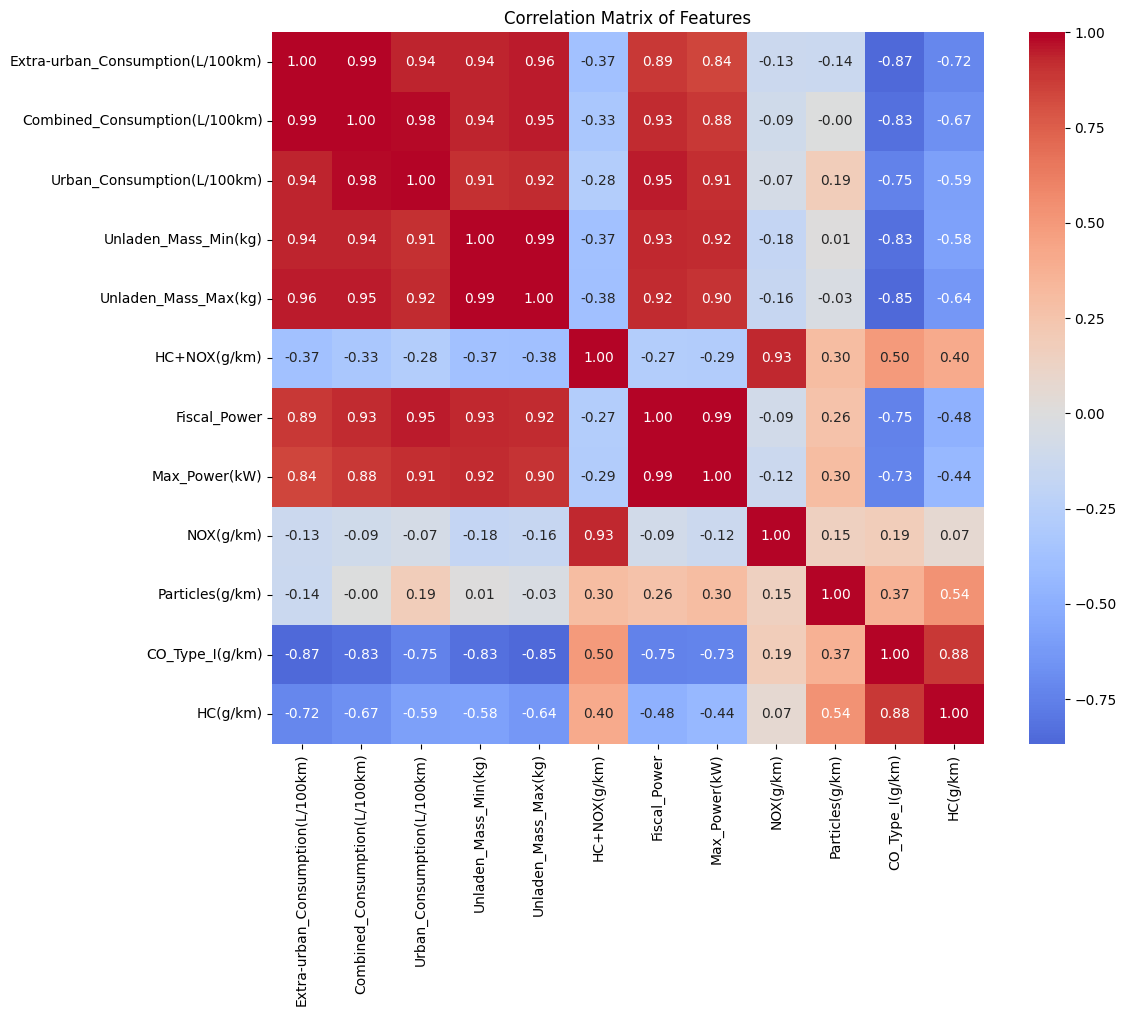


Highly correlated feature pairs (|correlation| >= 0.8):
                           Feature_1                      Feature_2  \
0   Extra-urban_Consumption(L/100km)  Combined_Consumption(L/100km)   
1   Extra-urban_Consumption(L/100km)     Urban_Consumption(L/100km)   
2   Extra-urban_Consumption(L/100km)           Unladen_Mass_Min(kg)   
3   Extra-urban_Consumption(L/100km)           Unladen_Mass_Max(kg)   
4   Extra-urban_Consumption(L/100km)                   Fiscal_Power   
5   Extra-urban_Consumption(L/100km)                  Max_Power(kW)   
6   Extra-urban_Consumption(L/100km)                CO_Type_I(g/km)   
7      Combined_Consumption(L/100km)     Urban_Consumption(L/100km)   
8      Combined_Consumption(L/100km)           Unladen_Mass_Min(kg)   
9      Combined_Consumption(L/100km)           Unladen_Mass_Max(kg)   
10     Combined_Consumption(L/100km)                   Fiscal_Power   
11     Combined_Consumption(L/100km)                  Max_Power(kW)   
12     Combined_Cons

In [28]:
# 1. Correlation matrix heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()

# 2. Identify highly correlated pairs
def find_high_correlations(corr_matrix, threshold=0.8):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr_pairs.append({
                    'Feature_1': corr_matrix.columns[i],
                    'Feature_2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs)

high_corr_df = find_high_correlations(correlation_matrix, 0.8)
print("\nHighly correlated feature pairs (|correlation| >= 0.8):")
print(high_corr_df)

Removing highly correlated features



In [29]:
recommended_features = [
    'Extra-urban_Consumption(L/100km)',  # Best single consumption measure
    'Unladen_Mass_Min(kg)',        # Better mass correlation with target
    'HC+NOX(g/km)',               # Better emission correlation with target  
    'Fiscal_Power',
    'Max_Power(kW)',
    'Particles(g/km)',
    'CO_Type_I(g/km)',
]

# Recalculate VIF with reduced feature set
X_reduced = df[recommended_features]
X_reduced = X_reduced.dropna()  # Drop rows with any NaN values
vif_data_reduced = pd.DataFrame()
vif_data_reduced["Feature"] = X_reduced.columns
vif_data_reduced["VIF"] = [variance_inflation_factor(X_reduced.values, i) 
                          for i in range(X_reduced.shape[1])]
print(vif_data_reduced.sort_values('VIF', ascending=False))

                            Feature         VIF
3                      Fiscal_Power  311.369466
0  Extra-urban_Consumption(L/100km)  270.012603
4                     Max_Power(kW)  239.201873
1              Unladen_Mass_Min(kg)  171.401178
2                      HC+NOX(g/km)   83.276451
6                   CO_Type_I(g/km)    4.055745
5                   Particles(g/km)    1.067548


In [30]:
# Recommended final features (keeping highest target correlation from each group)
final_features = [
    'Extra-urban_Consumption(L/100km)',  # Highest target correlation (0.907)
    'Unladen_Mass_Min(kg)',        # High target correlation (0.695)
    'HC+NOX(g/km)',               # High target correlation (0.673)
    'CO_Type_I(g/km)',            # Already acceptable VIF
    'Particles(g/km)'             # Already acceptable VIF
]
# Skip: Fiscal_Power and Max_Power(kW) - likely correlated with mass/consumption

# Calculate final VIF
X_final = df[final_features].dropna()
vif_final = pd.DataFrame()
vif_final["Feature"] = X_final.columns
vif_final["VIF"] = [variance_inflation_factor(X_final.values, i) 
                    for i in range(X_final.shape[1])]
print("Final VIF values:")
print(vif_final.sort_values('VIF', ascending=False))

Final VIF values:
                            Feature         VIF
0  Extra-urban_Consumption(L/100km)  195.513115
1              Unladen_Mass_Min(kg)  134.265713
2                      HC+NOX(g/km)   75.012611
3                   CO_Type_I(g/km)    2.881102
4                   Particles(g/km)    1.065388


In [31]:
final_features = [
    'Extra-urban_Consumption(L/100km)',  # Highest target correlation (0.907)        
    'CO_Type_I(g/km)',            # Already acceptable VIF
    'Particles(g/km)'             # Already acceptable VIF
]
# Skip: Fiscal_Power and Max_Power(kW) - likely correlated with mass/consumption

# Calculate final VIF
X_final = df[final_features].dropna()
vif_final = pd.DataFrame()
vif_final["Feature"] = X_final.columns
vif_final["VIF"] = [variance_inflation_factor(X_final.values, i) 
                    for i in range(X_final.shape[1])]
print("Final VIF values:")
print(vif_final.sort_values('VIF', ascending=False))

Final VIF values:
                            Feature       VIF
0  Extra-urban_Consumption(L/100km)  2.023945
1                   CO_Type_I(g/km)  2.011357
2                   Particles(g/km)  1.025883


We should decide if we remove some of them still or it is good as it is

Potential numerical variables for the model

- Extra-urban_Consumption(L/100km)
- Unladen_Mass_Min(kg)
- HC+NOX(g/km)
- CO_Type_I(g/km)
- Particles(g/km)


Potential Categorical Variable that could be used in the model

- Fuel_Type
- Hybrid
- Gearbox
- Body_Type
- Segment


In [32]:
df.columns

Index(['Brand', 'Project_Model', 'UTAC_Model', 'Commercial_Name', 'CNIT',
       'TVV', 'Fuel_Type', 'Hybrid', 'Fiscal_Power', 'Max_Power(kW)',
       'Gearbox', 'Urban_Consumption(L/100km)',
       'Extra-urban_Consumption(L/100km)', 'Combined_Consumption(L/100km)',
       'CO2(g/km)', 'CO_Type_I(g/km)', 'HC(g/km)', 'NOX(g/km)', 'HC+NOX(g/km)',
       'Particles(g/km)', 'Unladen_Mass_Min(kg)', 'Unladen_Mass_Max(kg)',
       'Field_V9', 'Update_Date', 'Body_Type', 'Segment'],
      dtype='object')

### Correlation of Variables

#### Does Fuel Type has a relationship with CO2 Emmissions

In order to see if the Maximal Mass has an influence in the CO2, we should <br>
differentiate those cars that use Gasoline/Diesel and the electric ones. Lets <br>
make first an exploration of how is the data of fuel type

In [33]:
df['Fuel_Type'].value_counts(normalize=True)

Fuel_Type
GO       0.842319
ES       0.137280
EH       0.004437
ES/GN    0.003924
GN/ES    0.003924
ES/GP    0.002230
GP/ES    0.002230
GN       0.001315
GH       0.001204
EL       0.000870
FE       0.000178
EE       0.000067
GL       0.000022
Name: proportion, dtype: float64

The first 3 Categories (GO, ES and EH) are already the 97% <br>
of the cars total. <br>
85% of the cars are driven with gasoline <br>
and 13% are diesel, below the 1% is hybrid

In [34]:
df['Fuel_Type'].value_counts(normalize=True).keys()[0:3]



Index(['GO', 'ES', 'EH'], dtype='object', name='Fuel_Type')

On the internet we could figure out, what GO, ES and EH mean

According to internet:
- ES: Gasoline
- GN: LPG
- GO: Diesel

In [35]:
labels = {"GO": "Gasoline", "ES":"Diesel", "EH": "hybrid"}

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_65232/1218593849.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(['Gasoline','Diesel','Hybrid'])


Text(0.5, 1.0, 'CO₂ Emissions by Fuel Type')

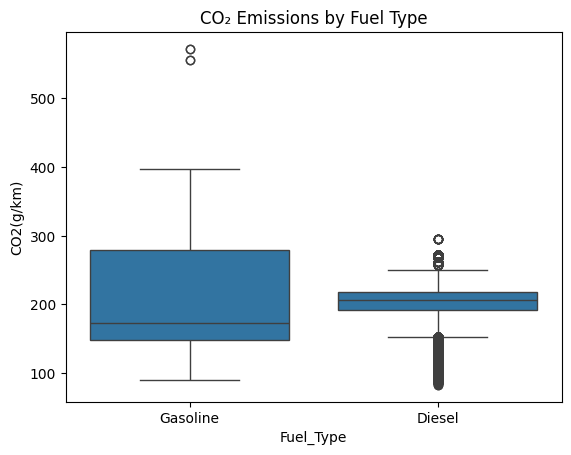

In [36]:
df_filter = df[(df['Fuel_Type'] == 'ES') | (df['Fuel_Type'] == 'GO')]

fig = sns.boxplot(x=df_filter['Fuel_Type'], y=df_filter['CO2(g/km)'])

fig.set_xticklabels(['Gasoline','Diesel','Hybrid'])

plt.title('CO₂ Emissions by Fuel Type')


The mean between gasoline and diesel has a difference, is this <br>
a significant difference? <br>

let's apply Welch's t-test in order to respond this question:<br>
<br>
    - H0: There is no significant difference in the CO2 Consumption<br>
    levels between Gasoline and Diesel.<br>
    <br>
    - H1: There is a significant difference in the CO2 Consumption <br>
    levels between Gasoline and Diesel.<br>
        

In [37]:
from scipy.stats import ttest_ind

# Filter CO₂ data for each fuel type
es_co2 = df_filter[df_filter['Fuel_Type'] == 'ES']['CO2(g/km)']
go_co2 = df_filter[df_filter['Fuel_Type'] == 'GO']['CO2(g/km)']

# Apply Welch's t-test (does not assume equal variances)
t_stat, p_value = ttest_ind(es_co2, go_co2, equal_var=False)

print("T-statistic:", t_stat)
print("p-value:", p_value)

if p_value>0.05:
    print("p_value>0.05 Fail to reject the null (not significant difference)")
else:
    print("p_value<0.05 Reject the null hypothesis (significant difference)")

T-statistic: 0.3724281026518655
p-value: 0.7095860630521096
p_value>0.05 Fail to reject the null (not significant difference)


=== FUEL TYPE AND CO2 EMISSIONS ANALYSIS ===

1. Basic Statistics:
Total records: 44850
Fuel types: 13
Fuel type distribution:
Fuel_Type
GO       37778
ES        6157
EH         199
ES/GN      176
GN/ES      176
ES/GP      100
GP/ES      100
GN          59
GH          54
EL          39
FE           8
EE           3
GL           1
Name: count, dtype: int64

2. CO2 Emissions by Fuel Type:
           count    mean  median    std    min    max
Fuel_Type                                            
EE             3   34.33    27.0  12.70   27.0   49.0
EH           199  154.60   153.0  36.91   79.0  256.0
EL             0     NaN     NaN    NaN    NaN    NaN
ES          6157  199.84   173.0  65.96   90.0  572.0
ES/GN        176  220.68   289.0  77.40  107.0  289.0
ES/GP        100  147.04   136.0  30.98  119.0  225.0
FE             8  204.88   197.5  37.84  170.0  246.0
GH            54  110.81   111.0   7.28   88.0  119.0
GL             1   48.00    48.0    NaN   48.0   48.0
GN            59

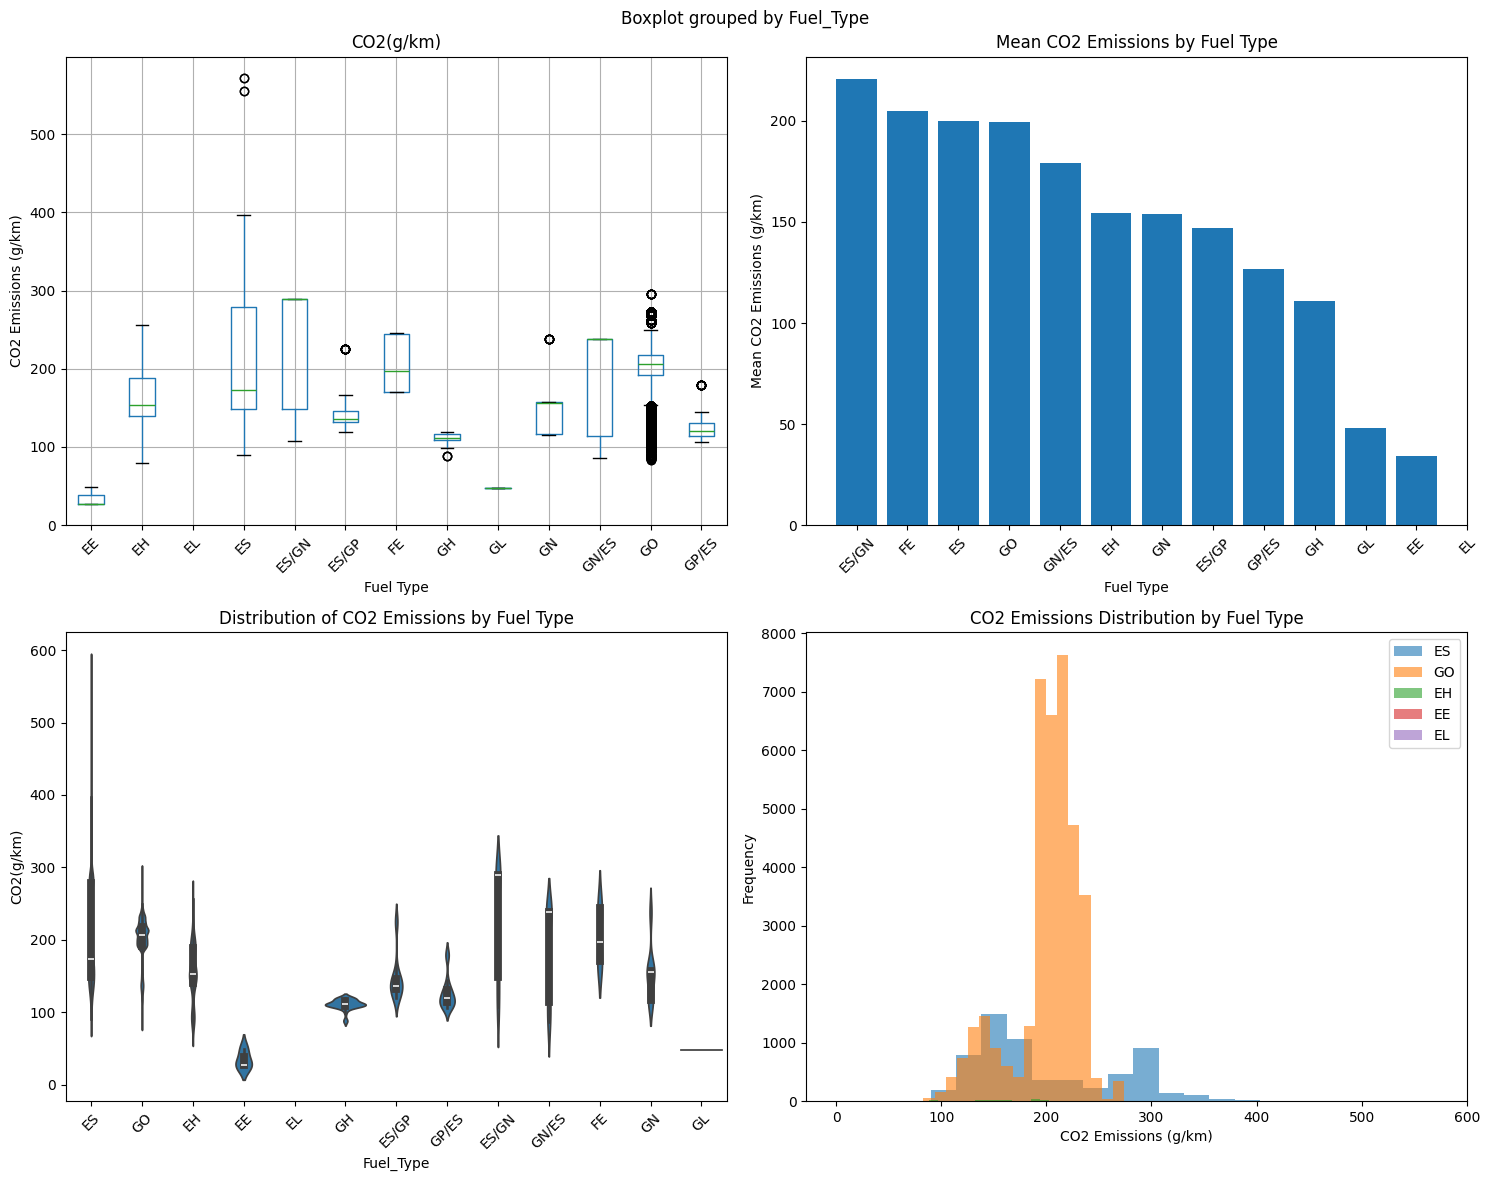


4. Effect Size:
Eta-squared: 0.0293
Effect size: Medium

5. Post-hoc Analysis (Tukey's HSD):
Tukey's HSD could not be performed - using alternative pairwise tests

=== CONCLUSION ===
There IS a statistically significant difference in CO2 emissions between fuel types.
This suggests that fuel type has a meaningful impact on CO2 emissions.


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

# 1. Exploratory Data Analysis
print("=== FUEL TYPE AND CO2 EMISSIONS ANALYSIS ===")
print("\n1. Basic Statistics:")
print(f"Total records: {len(df)}")
print(f"Fuel types: {df['Fuel_Type'].nunique()}")
print(f"Fuel type distribution:")
print(df['Fuel_Type'].value_counts())

# 2. Descriptive Statistics by Fuel Type
print("\n2. CO2 Emissions by Fuel Type:")
co2_by_fuel = df.groupby('Fuel_Type')['CO2(g/km)'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
print(co2_by_fuel)

# 3. Statistical Test - ANOVA
print("\n3. ANOVA Test:")
fuel_groups = []
for fuel_type in df['Fuel_Type'].unique():
    if pd.notna(fuel_type):  # Exclude NaN values
        group_data = df[df['Fuel_Type'] == fuel_type]['CO2(g/km)'].dropna()
        if len(group_data) > 0:
            fuel_groups.append(group_data)

# Perform ANOVA
f_stat, p_value = f_oneway(*fuel_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level: 0.05")
print(f"Result: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")

# 4. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Box plot
axes[0,0].set_title('CO2 Emissions by Fuel Type')
df.boxplot(column='CO2(g/km)', by='Fuel_Type', ax=axes[0,0])
axes[0,0].set_xlabel('Fuel Type')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].tick_params(axis='x', rotation=45)

# Bar plot of means
fuel_means = df.groupby('Fuel_Type')['CO2(g/km)'].mean().sort_values(ascending=False)
axes[0,1].bar(range(len(fuel_means)), fuel_means.values)
axes[0,1].set_title('Mean CO2 Emissions by Fuel Type')
axes[0,1].set_xlabel('Fuel Type')
axes[0,1].set_ylabel('Mean CO2 Emissions (g/km)')
axes[0,1].set_xticks(range(len(fuel_means)))
axes[0,1].set_xticklabels(fuel_means.index, rotation=45)

# Violin plot
sns.violinplot(data=df, x='Fuel_Type', y='CO2(g/km)', ax=axes[1,0])
axes[1,0].set_title('Distribution of CO2 Emissions by Fuel Type')
axes[1,0].tick_params(axis='x', rotation=45)

# Histogram
for fuel_type in df['Fuel_Type'].unique()[:5]:  # Show top 5 fuel types
    if pd.notna(fuel_type):
        data = df[df['Fuel_Type'] == fuel_type]['CO2(g/km)'].dropna()
        axes[1,1].hist(data, alpha=0.6, label=fuel_type, bins=20)
axes[1,1].set_title('CO2 Emissions Distribution by Fuel Type')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# 5. Effect Size (Eta-squared)
print(f"\n4. Effect Size:")
# Calculate eta-squared
ss_between = sum([len(group) * (group.mean() - df['CO2(g/km)'].mean())**2 
                  for group in fuel_groups])
ss_total = ((df['CO2(g/km)'] - df['CO2(g/km)'].mean())**2).sum()
eta_squared = ss_between / ss_total
print(f"Eta-squared: {eta_squared:.4f}")
print(f"Effect size: {'Small' if eta_squared < 0.01 else 'Medium' if eta_squared < 0.06 else 'Large'}")

# 6. Post-hoc analysis (if ANOVA is significant)
if p_value < 0.05:
    print("\n5. Post-hoc Analysis (Tukey's HSD):")
    from scipy.stats import tukey_hsd
    
    # Prepare data for Tukey's HSD
    fuel_types = []
    co2_values = []
    for fuel_type in df['Fuel_Type'].unique():
        if pd.notna(fuel_type):
            fuel_data = df[df['Fuel_Type'] == fuel_type]['CO2(g/km)'].dropna()
            fuel_types.extend([fuel_type] * len(fuel_data))
            co2_values.extend(fuel_data.values)
    
    # Perform Tukey's HSD
    try:
        tukey_result = tukey_hsd(*fuel_groups)
        print("Pairwise comparisons:")
        for i, fuel1 in enumerate(df['Fuel_Type'].unique()):
            for j, fuel2 in enumerate(df['Fuel_Type'].unique()):
                if i < j and pd.notna(fuel1) and pd.notna(fuel2):
                    print(f"{fuel1} vs {fuel2}: p-value = {tukey_result.pvalue[i,j]:.6f}")
    except:
        print("Tukey's HSD could not be performed - using alternative pairwise tests")

print("\n=== CONCLUSION ===")
if p_value < 0.05:
    print("There IS a statistically significant difference in CO2 emissions between fuel types.")
    print("This suggests that fuel type has a meaningful impact on CO2 emissions.")
else:
    print("There is NO statistically significant difference in CO2 emissions between fuel types.")
    print("This suggests that fuel type may not have a meaningful impact on CO2 emissions in this dataset.")

#### Does Maximal mass has a relationship with CO2 Emmissions

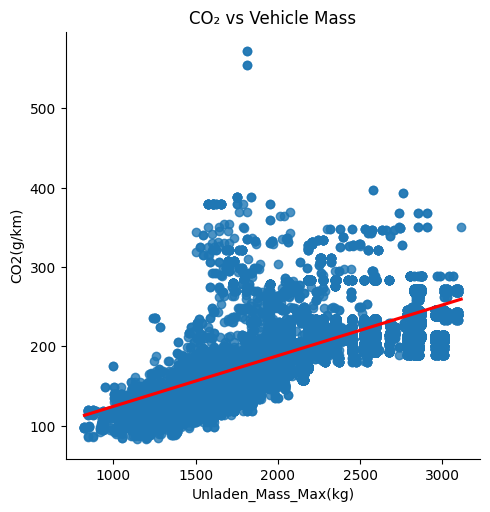

In [39]:
sns.lmplot(x='Unladen_Mass_Max(kg)', y='CO2(g/km)',
           line_kws={'color': 'red'},
           data= df_filter)
plt.title('CO₂ vs Vehicle Mass')
plt.show()

it seems to be a relationship between Mass and CO2 <br>

let's make "Pearson's r" test perform to see if there is a linear <br>
correlation

In [40]:
# Example: mass vs CO2
from scipy.stats import pearsonr
r, p = pearsonr(df_filter['Unladen_Mass_Max(kg)'], df_filter['CO2(g/km)'])

print("Correlation coefficient (r):", r)
print("p-value:", p)


Correlation coefficient (r): 0.6724436516215779
p-value: 0.0


The r value is high so there is strong positive correlation <br>
and the p-value: < 0.05, so it is significant the relationship <br>
so: Does Maximal mass has a relationship with CO2 Emissions?<br>
YES it has a strong positive relationship

#### Does the gear box type has a relationship with CO2 Emmisions?

In [41]:
df_filter['Gearbox'].value_counts(normalize=True)

Gearbox
M 6    0.438671
A 5    0.308797
A 7    0.188506
M 5    0.025265
A 6    0.024878
A 8    0.009764
V 0    0.001343
D 5    0.000888
A 4    0.000865
D 7    0.000478
M 7    0.000273
D 6    0.000250
S 6    0.000023
Name: proportion, dtype: float64

In [42]:
df_filter

,Brand,Project_Model,UTAC_Model,Commercial_Name,CNIT,TVV,Fuel_Type,Hybrid,Fiscal_Power,Max_Power(kW),Gearbox,Urban_Consumption(L/100km),Extra-urban_Consumption(L/100km),Combined_Consumption(L/100km),CO2(g/km),CO_Type_I(g/km),HC(g/km),NOX(g/km),HC+NOX(g/km),Particles(g/km),Unladen_Mass_Min(kg),Unladen_Mass_Max(kg),Field_V9,Update_Date,Body_Type,Segment
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12.0,147.0,M 6,11.3,5.8,7.8,182.0,0.647,0.052,0.032,NaN,0.002,1505.0,1505.0,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
1,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9.0,125.0,M 6,6.6,4.3,5.1,136.0,0.192,NaN,0.169,0.190,0.003,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7.0,100.0,M 6,6.6,4.2,5.1,134.0,0.066,NaN,0.149,0.175,0.001,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7.0,100.0,M 6,6.6,4.2,5.1,134.0,0.066,NaN,0.149,0.175,0.001,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9.0,125.0,M 6,6.9,4.3,5.3,139.0,0.060,NaN,0.164,0.193,0.001,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44845,VOLVO,XC70,XC70,XC70 D4 (163ch) AWD Geartronic 6,M10VLVVP874P723,BZ8756,GO,non,10.0,120.0,A 6,8.6,5.2,6.4,169.0,0.344,NaN,0.116,0.152,0.000,1799.0,1799.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44846,VOLVO,XC70,XC70,XC70 D4 (163ch) Stop&Start AWD BVM6,M10VLVVP8725584,BZ87A4,GO,non,9.0,120.0,M 6,6.1,4.8,5.3,139.0,0.285,NaN,0.106,0.144,0.000,1786.0,1786.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44847,VOLVO,XC70,XC70,XC70 D4 (163ch) Geartronic 6,M10VLVVP8726585,BZ8850,GO,non,9.0,120.0,A 6,7.7,4.8,5.9,154.0,0.243,NaN,0.108,0.132,0.001,1726.0,1726.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44848,VOLVO,XC70,XC70,XC70 D4 (163ch) Stop&Start BVM6,M10VLVVP8727586,BZ88A1,GO,non,9.0,120.0,M 6,6.8,4.5,5.3,139.0,0.268,NaN,0.127,0.152,0.001,1706.0,1706.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE


In [43]:
main_gb = ['M 6','A 5','A 7'] #90% of the data falls into these three categories

df_filter_mgb = df_filter[df_filter['Gearbox'].isin(main_gb)]


In [44]:
df_filter_mgb['Gearbox'].value_counts(normalize=True)

Gearbox
M 6    0.468679
A 5    0.329921
A 7    0.201401
Name: proportion, dtype: float64

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_65232/298571972.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(['Manual 6 ','Autom. 5','Autom. 7'])


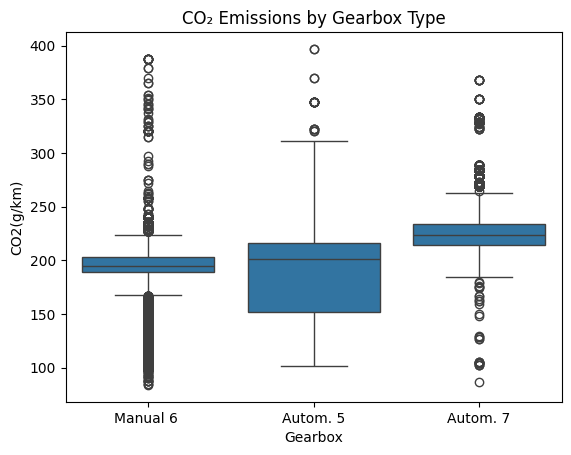

In [45]:

fig = sns.boxplot(x=df_filter_mgb['Gearbox'], y=df_filter_mgb['CO2(g/km)'])

fig.set_xticklabels(['Manual 6 ','Autom. 5','Autom. 7'])
plt.title('CO₂ Emissions by Gearbox Type')

plt.show()


Between Manual and automatic 5 (5 gears) there is a slightly <br>
difference in the mean. The automatic 7 has a higher mean than the<br>
other two. But is it this difference due to the gearbox type <br>
or because this 'gearbox' type are mainly to see in "sport" cars <br>
or  in cars bigger than standard cars? <br>. In those cases the <br> 
cylinders are bigger and therefore more CO2 consumption?


=== Gearbox AND CO2 EMISSIONS ANALYSIS ===

1. Basic Statistics:
Total records: 44850
Gearboxs: 16
Gearbox distribution:
Gearbox
M 6    19364
A 5    13770
A 7     8428
M 5     1425
A 6     1101
A 8      446
V 0      180
A 4       39
D 5       39
D 7       21
M 7       12
D 6       11
A 0       10
N 1        2
S 6        1
N 0        1
Name: count, dtype: int64

2. CO2 Emissions by Gearbox:
         count    mean  median    std    min    max
Gearbox                                            
A 0          0     NaN     NaN    NaN    NaN    NaN
A 4         39  150.97   150.0  23.03  118.0  256.0
A 5      13770  229.50   224.0  22.40   87.0  368.0
A 6       1101  181.10   166.0  61.53   48.0  572.0
A 7       8428  186.81   199.0  40.19   95.0  397.0
A 8        446  201.56   184.0  62.42  109.0  393.0
D 5         39  123.38   130.0  18.73   90.0  163.0
D 6         11  139.91   121.0  65.38  119.0  337.0
D 7         21  307.33   299.0  39.03  270.0  380.0
M 5       1425  129.14   129.0  25.

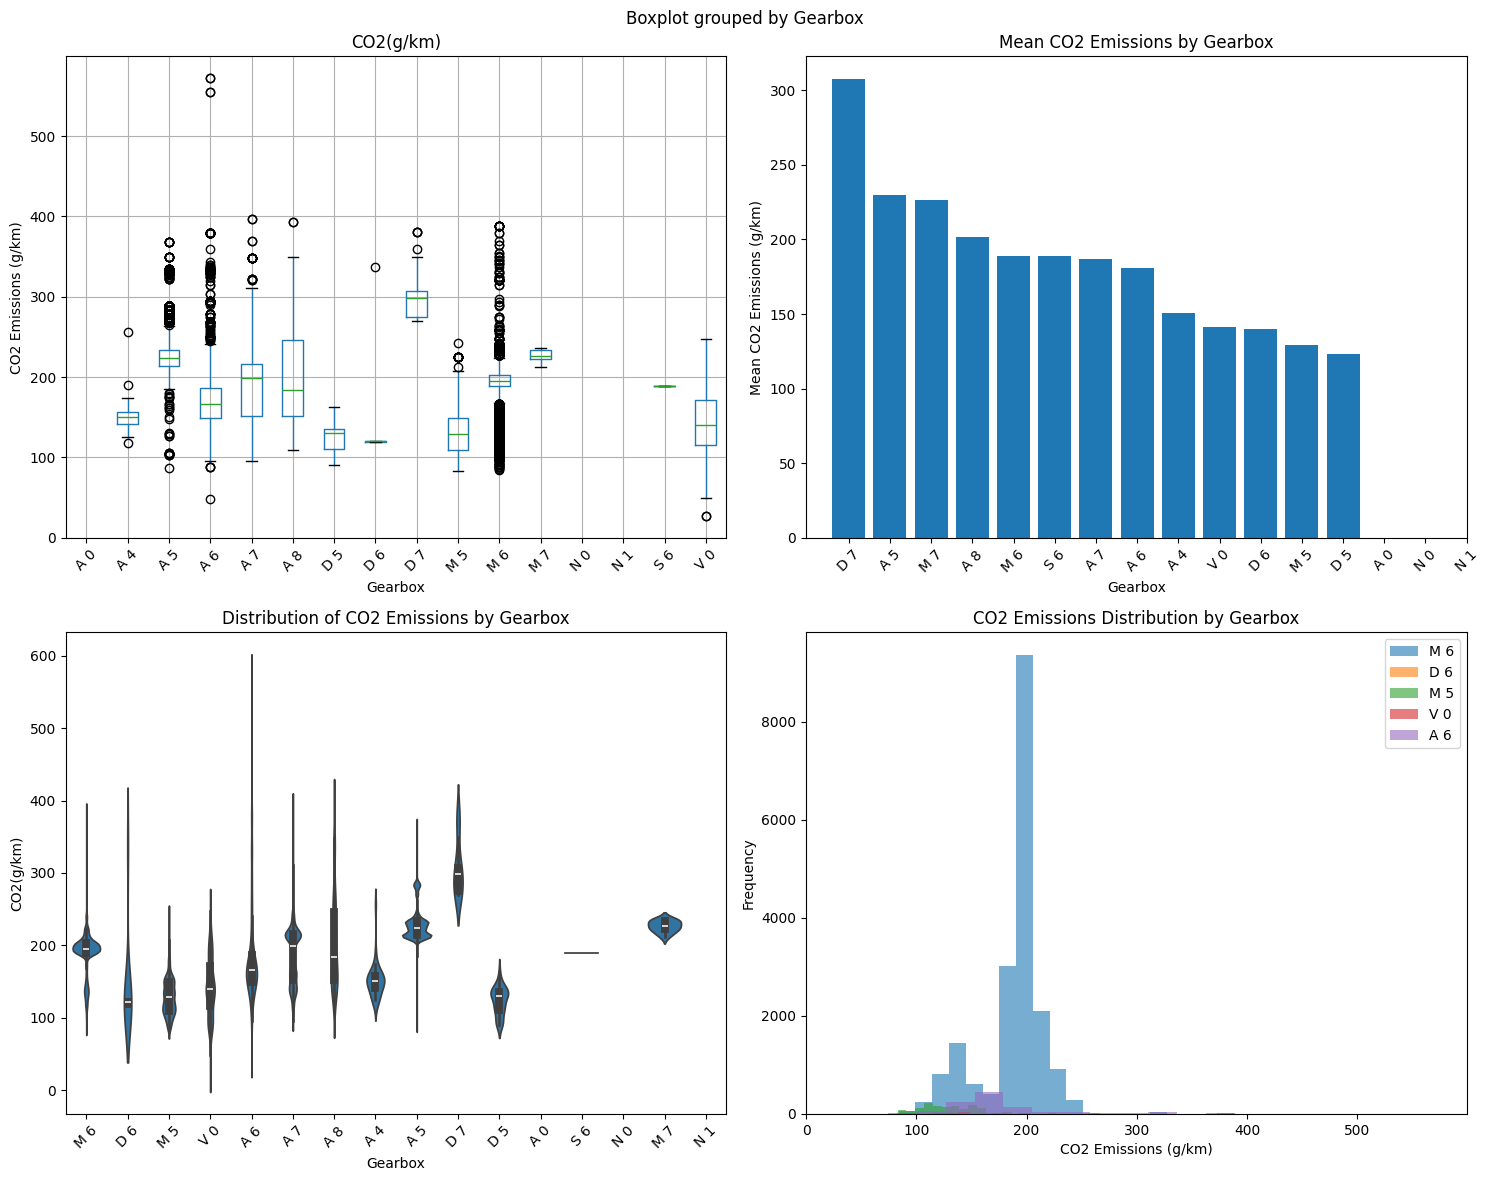


4. Effect Size:
Eta-squared: 0.3575
Effect size: Large

5. Post-hoc Analysis (Tukey's HSD):
Tukey's HSD could not be performed - using alternative pairwise tests

=== CONCLUSION ===
There IS a statistically significant difference in CO2 emissions between Gearboxs.
This suggests that Gearbox has a meaningful impact on CO2 emissions.


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

# 1. Exploratory Data Analysis
print("=== Gearbox AND CO2 EMISSIONS ANALYSIS ===")
print("\n1. Basic Statistics:")
print(f"Total records: {len(df)}")
print(f"Gearboxs: {df['Gearbox'].nunique()}")
print(f"Gearbox distribution:")
print(df['Gearbox'].value_counts())

# 2. Descriptive Statistics by Gearbox
print("\n2. CO2 Emissions by Gearbox:")
co2_by_fuel = df.groupby('Gearbox')['CO2(g/km)'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
print(co2_by_fuel)

# 3. Statistical Test - ANOVA
print("\n3. ANOVA Test:")
fuel_groups = []
for Gearbox in df['Gearbox'].unique():
    if pd.notna(Gearbox):  # Exclude NaN values
        group_data = df[df['Gearbox'] == Gearbox]['CO2(g/km)'].dropna()
        if len(group_data) > 0:
            fuel_groups.append(group_data)

# Perform ANOVA
f_stat, p_value = f_oneway(*fuel_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level: 0.05")
print(f"Result: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")

# 4. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Box plot
axes[0,0].set_title('CO2 Emissions by Gearbox')
df.boxplot(column='CO2(g/km)', by='Gearbox', ax=axes[0,0])
axes[0,0].set_xlabel('Gearbox')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].tick_params(axis='x', rotation=45)

# Bar plot of means
fuel_means = df.groupby('Gearbox')['CO2(g/km)'].mean().sort_values(ascending=False)
axes[0,1].bar(range(len(fuel_means)), fuel_means.values)
axes[0,1].set_title('Mean CO2 Emissions by Gearbox')
axes[0,1].set_xlabel('Gearbox')
axes[0,1].set_ylabel('Mean CO2 Emissions (g/km)')
axes[0,1].set_xticks(range(len(fuel_means)))
axes[0,1].set_xticklabels(fuel_means.index, rotation=45)

# Violin plot
sns.violinplot(data=df, x='Gearbox', y='CO2(g/km)', ax=axes[1,0])
axes[1,0].set_title('Distribution of CO2 Emissions by Gearbox')
axes[1,0].tick_params(axis='x', rotation=45)

# Histogram
for Gearbox in df['Gearbox'].unique()[:5]:  # Show top 5 Gearboxs
    if pd.notna(Gearbox):
        data = df[df['Gearbox'] == Gearbox]['CO2(g/km)'].dropna()
        axes[1,1].hist(data, alpha=0.6, label=Gearbox, bins=20)
axes[1,1].set_title('CO2 Emissions Distribution by Gearbox')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# 5. Effect Size (Eta-squared)
print(f"\n4. Effect Size:")
# Calculate eta-squared
ss_between = sum([len(group) * (group.mean() - df['CO2(g/km)'].mean())**2 
                  for group in fuel_groups])
ss_total = ((df['CO2(g/km)'] - df['CO2(g/km)'].mean())**2).sum()
eta_squared = ss_between / ss_total
print(f"Eta-squared: {eta_squared:.4f}")
print(f"Effect size: {'Small' if eta_squared < 0.01 else 'Medium' if eta_squared < 0.06 else 'Large'}")

# 6. Post-hoc analysis (if ANOVA is significant)
if p_value < 0.05:
    print("\n5. Post-hoc Analysis (Tukey's HSD):")
    from scipy.stats import tukey_hsd
    
    # Prepare data for Tukey's HSD
    Gearboxs = []
    co2_values = []
    for Gearbox in df['Gearbox'].unique():
        if pd.notna(Gearbox):
            fuel_data = df[df['Gearbox'] == Gearbox]['CO2(g/km)'].dropna()
            Gearboxs.extend([Gearbox] * len(fuel_data))
            co2_values.extend(fuel_data.values)
    
    # Perform Tukey's HSD
    try:
        tukey_result = tukey_hsd(*fuel_groups)
        print("Pairwise comparisons:")
        for i, fuel1 in enumerate(df['Gearbox'].unique()):
            for j, fuel2 in enumerate(df['Gearbox'].unique()):
                if i < j and pd.notna(fuel1) and pd.notna(fuel2):
                    print(f"{fuel1} vs {fuel2}: p-value = {tukey_result.pvalue[i,j]:.6f}")
    except:
        print("Tukey's HSD could not be performed - using alternative pairwise tests")

print("\n=== CONCLUSION ===")
if p_value < 0.05:
    print("There IS a statistically significant difference in CO2 emissions between Gearboxs.")
    print("This suggests that Gearbox has a meaningful impact on CO2 emissions.")
else:
    print("There is NO statistically significant difference in CO2 emissions between Gearboxs.")
    print("This suggests that Gearbox may not have a meaningful impact on CO2 emissions in this dataset.")

In [47]:
df_filter_mgb[df_filter_mgb['Gearbox'] == 'A 7']['Body_Type'].value_counts(normalize=True)

Body_Type
MINIBUS                0.412340
BERLINE                0.243057
BREAK                  0.143927
COUPE                  0.064598
TS TERRAINS/CHEMINS    0.062545
CABRIOLET              0.033084
MONOSPACE COMPACT      0.028013
COMBISPACE             0.012437
Name: proportion, dtype: float64

We don't see really a pattern

#### Does the segment has a relationship with CO2 Consumption?

In [48]:
df_filter['Segment'].value_counts(normalize=True)

Segment
MOY-INFER     0.458382
MOY-SUPER     0.344008
LUXE          0.114100
SUPERIEURE    0.044338
INFERIEURE    0.034915
ECONOMIQUE    0.004211
MOY-INF       0.000046
Name: proportion, dtype: float64

In [49]:
main_seg = df_filter["Segment"].value_counts().index[:4]

main_seg

Index(['MOY-INFER', 'MOY-SUPER', 'LUXE', 'SUPERIEURE'], dtype='object', name='Segment')

In [50]:
df_filter_seg = df[df["Segment"].isin(main_seg)]

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_65232/627092353.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(['Lower-Mid Segment', 'Upper-Mid Segment ', 'Luxury', 'Upper Segment'])


[Text(0, 0, 'Lower-Mid Segment'),
 Text(1, 0, 'Upper-Mid Segment '),
 Text(2, 0, 'Luxury'),
 Text(3, 0, 'Upper Segment')]

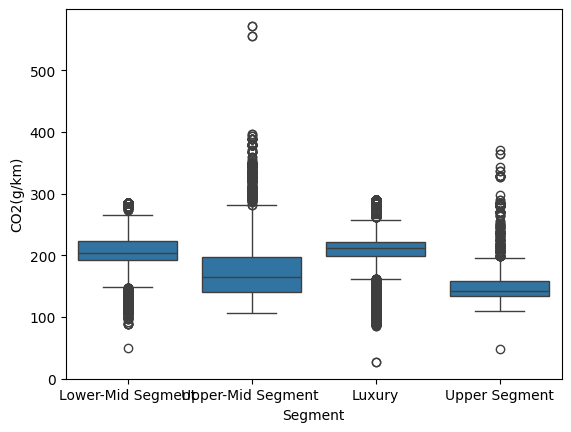

In [51]:

fig = sns.boxplot(x=df_filter_seg['Segment'], y=df_filter_seg['CO2(g/km)'])

fig.set_xticklabels(['Lower-Mid Segment', 'Upper-Mid Segment ', 'Luxury', 'Upper Segment'])



=== Segment AND CO2 EMISSIONS ANALYSIS ===

1. Basic Statistics:
Total records: 44850
Segments: 7
Segment distribution:
Segment
MOY-INFER     20428
MOY-SUPER     15124
LUXE           5223
SUPERIEURE     1956
INFERIEURE     1884
ECONOMIQUE      233
MOY-INF           2
Name: count, dtype: int64

2. CO2 Emissions by Segment:
            count    mean  median    std    min    max
Segment                                               
ECONOMIQUE    201  113.51   112.0  14.97   85.0  155.0
INFERIEURE   1884  137.97   139.0  24.35   79.0  225.0
LUXE         5219  179.83   164.0  54.81  107.0  572.0
MOY-INF         2  150.00   150.0   0.00  150.0  150.0
MOY-INFER   20426  207.56   211.0  31.38   27.0  289.0
MOY-SUPER   15124  208.28   203.0  27.54   49.0  284.0
SUPERIEURE   1955  154.57   142.0  37.33   48.0  370.0

3. ANOVA Test:
F-statistic: 2492.2787
P-value: 0.000000
Significance level: 0.05
Result: Reject H₀


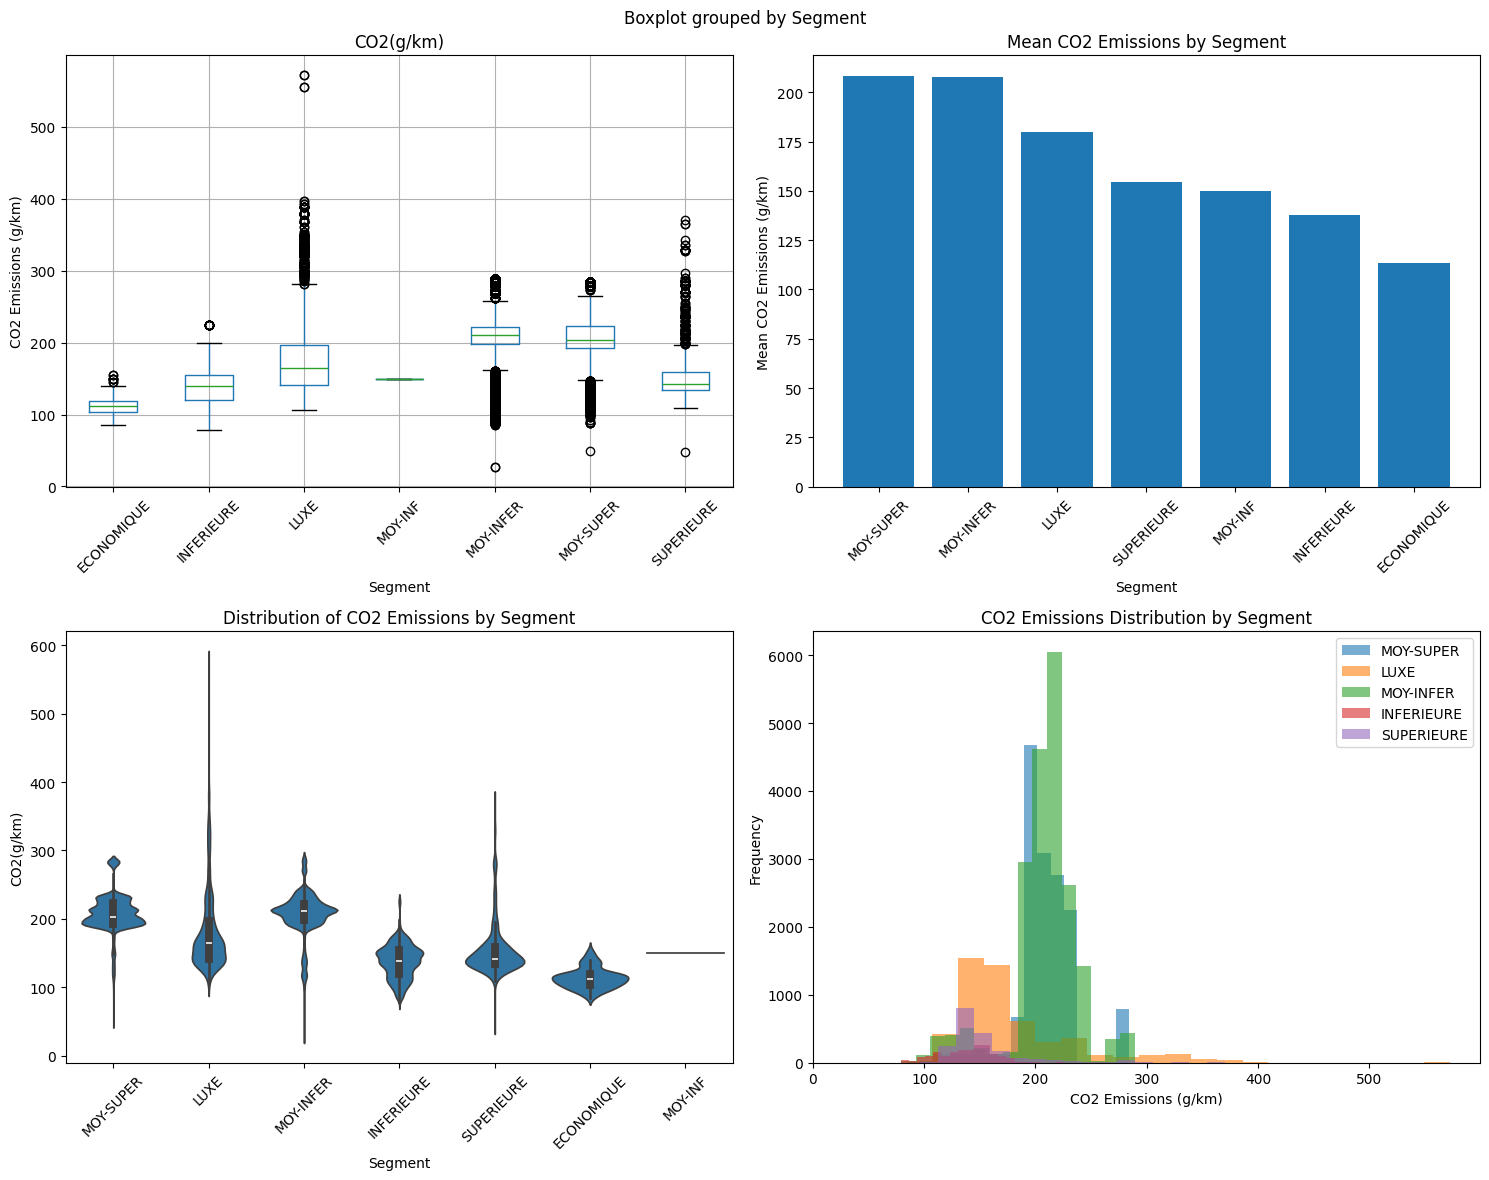


4. Effect Size:
Eta-squared: 0.2502
Effect size: Large

5. Post-hoc Analysis (Tukey's HSD):
Pairwise comparisons:
MOY-SUPER vs LUXE: p-value = 0.000000
MOY-SUPER vs MOY-INFER: p-value = 0.434100
MOY-SUPER vs INFERIEURE: p-value = 0.000000
MOY-SUPER vs SUPERIEURE: p-value = 0.000000
MOY-SUPER vs ECONOMIQUE: p-value = 0.000000
MOY-SUPER vs MOY-INF: p-value = 0.182245
LUXE vs MOY-INFER: p-value = 0.000000
LUXE vs INFERIEURE: p-value = 0.000000
LUXE vs SUPERIEURE: p-value = 0.000000
LUXE vs ECONOMIQUE: p-value = 0.000000
LUXE vs MOY-INF: p-value = 0.875058
MOY-INFER vs INFERIEURE: p-value = 0.000000
MOY-INFER vs SUPERIEURE: p-value = 0.000000
MOY-INFER vs ECONOMIQUE: p-value = 0.000000
MOY-INFER vs MOY-INF: p-value = 0.194429
INFERIEURE vs SUPERIEURE: p-value = 0.000000
INFERIEURE vs ECONOMIQUE: p-value = 0.000000
INFERIEURE vs MOY-INF: p-value = 0.998819
SUPERIEURE vs ECONOMIQUE: p-value = 0.000000
SUPERIEURE vs MOY-INF: p-value = 0.999996
ECONOMIQUE vs MOY-INF: p-value = 0.732988

=== C

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

# 1. Exploratory Data Analysis
print("=== Segment AND CO2 EMISSIONS ANALYSIS ===")
print("\n1. Basic Statistics:")
print(f"Total records: {len(df)}")
print(f"Segments: {df['Segment'].nunique()}")
print(f"Segment distribution:")
print(df['Segment'].value_counts())

# 2. Descriptive Statistics by Segment
print("\n2. CO2 Emissions by Segment:")
co2_by_fuel = df.groupby('Segment')['CO2(g/km)'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
print(co2_by_fuel)

# 3. Statistical Test - ANOVA
print("\n3. ANOVA Test:")
fuel_groups = []
for Segment in df['Segment'].unique():
    if pd.notna(Segment):  # Exclude NaN values
        group_data = df[df['Segment'] == Segment]['CO2(g/km)'].dropna()
        if len(group_data) > 0:
            fuel_groups.append(group_data)

# Perform ANOVA
f_stat, p_value = f_oneway(*fuel_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level: 0.05")
print(f"Result: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")

# 4. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Box plot
axes[0,0].set_title('CO2 Emissions by Segment')
df.boxplot(column='CO2(g/km)', by='Segment', ax=axes[0,0])
axes[0,0].set_xlabel('Segment')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].tick_params(axis='x', rotation=45)

# Bar plot of means
fuel_means = df.groupby('Segment')['CO2(g/km)'].mean().sort_values(ascending=False)
axes[0,1].bar(range(len(fuel_means)), fuel_means.values)
axes[0,1].set_title('Mean CO2 Emissions by Segment')
axes[0,1].set_xlabel('Segment')
axes[0,1].set_ylabel('Mean CO2 Emissions (g/km)')
axes[0,1].set_xticks(range(len(fuel_means)))
axes[0,1].set_xticklabels(fuel_means.index, rotation=45)

# Violin plot
sns.violinplot(data=df, x='Segment', y='CO2(g/km)', ax=axes[1,0])
axes[1,0].set_title('Distribution of CO2 Emissions by Segment')
axes[1,0].tick_params(axis='x', rotation=45)

# Histogram
for Segment in df['Segment'].unique()[:5]:  # Show top 5 Segments
    if pd.notna(Segment):
        data = df[df['Segment'] == Segment]['CO2(g/km)'].dropna()
        axes[1,1].hist(data, alpha=0.6, label=Segment, bins=20)
axes[1,1].set_title('CO2 Emissions Distribution by Segment')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# 5. Effect Size (Eta-squared)
print(f"\n4. Effect Size:")
# Calculate eta-squared
ss_between = sum([len(group) * (group.mean() - df['CO2(g/km)'].mean())**2 
                  for group in fuel_groups])
ss_total = ((df['CO2(g/km)'] - df['CO2(g/km)'].mean())**2).sum()
eta_squared = ss_between / ss_total
print(f"Eta-squared: {eta_squared:.4f}")
print(f"Effect size: {'Small' if eta_squared < 0.01 else 'Medium' if eta_squared < 0.06 else 'Large'}")

# 6. Post-hoc analysis (if ANOVA is significant)
if p_value < 0.05:
    print("\n5. Post-hoc Analysis (Tukey's HSD):")
    from scipy.stats import tukey_hsd
    
    # Prepare data for Tukey's HSD
    Segments = []
    co2_values = []
    for Segment in df['Segment'].unique():
        if pd.notna(Segment):
            fuel_data = df[df['Segment'] == Segment]['CO2(g/km)'].dropna()
            Segments.extend([Segment] * len(fuel_data))
            co2_values.extend(fuel_data.values)
    
    # Perform Tukey's HSD
    try:
        tukey_result = tukey_hsd(*fuel_groups)
        print("Pairwise comparisons:")
        for i, fuel1 in enumerate(df['Segment'].unique()):
            for j, fuel2 in enumerate(df['Segment'].unique()):
                if i < j and pd.notna(fuel1) and pd.notna(fuel2):
                    print(f"{fuel1} vs {fuel2}: p-value = {tukey_result.pvalue[i,j]:.6f}")
    except:
        print("Tukey's HSD could not be performed - using alternative pairwise tests")

print("\n=== CONCLUSION ===")
if p_value < 0.05:
    print("There IS a statistically significant difference in CO2 emissions between Segments.")
    print("This suggests that Segment has a meaningful impact on CO2 emissions.")
else:
    print("There is NO statistically significant difference in CO2 emissions between Segments.")
    print("This suggests that Segment may not have a meaningful impact on CO2 emissions in this dataset.")

#### Does Max Power has a relationship with CO2 Consumption?

In [53]:
df_filter['Body_Type'].value_counts(normalize=True)

Body_Type
MINIBUS                0.740731
BERLINE                0.103539
BREAK                  0.051303
TS TERRAINS/CHEMINS    0.027518
COUPE                  0.024969
COMBISPACE             0.019051
CABRIOLET              0.013725
MONOSPACE COMPACT      0.013429
MINISPACE              0.003141
MONOSPACE              0.002595
Name: proportion, dtype: float64

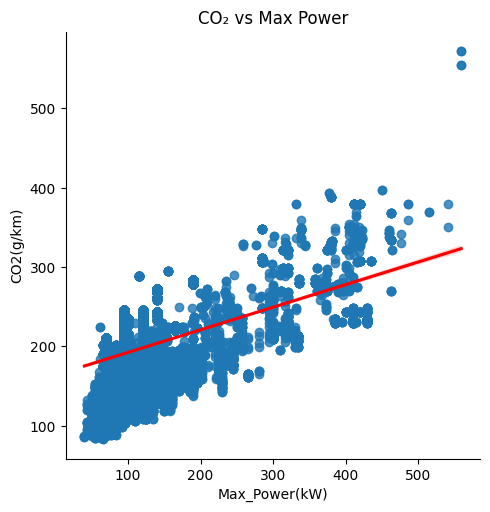

In [54]:
sns.lmplot(x='Max_Power(kW)', y='CO2(g/km)',
            line_kws={'color': 'red'},
           data= df_filter)
plt.title('CO₂ vs Max Power')
plt.show()

The Max Power seems to be strongly related with CO2 emmsion, this <br>
makes sense because 
is also other hypothesis we have to explore

In [55]:
# Mass vs CO2
r, p = pearsonr(df_filter['Max_Power(kW)'], df_filter['CO2(g/km)'])

print("Correlation coefficient (r):", r)
print("p-value:", p)

Correlation coefficient (r): 0.3646880782020383
p-value: 0.0


it has a moderate relationship, not strong as <br>
mass though.<br>
This makes sense mechanically too — heavier cars naturally <br>
require more fuel, regardless of how powerful the engine is.

#### Does Body Type has a relationship with CO2 Consumption?

In [56]:
main_bt = df_filter['Body_Type'].value_counts(normalize=True).index[:5]
main_bt

Index(['MINIBUS', 'BERLINE', 'BREAK', 'TS TERRAINS/CHEMINS', 'COUPE'], dtype='object', name='Body_Type')

In [57]:
#filter main body types (for visualisation)
df_filter_bt = df_filter[df_filter['Body_Type'].isin(main_bt)]

In [58]:
df_filter_bt['Body_Type'].value_counts()

Body_Type
MINIBUS                32544
BERLINE                 4549
BREAK                   2254
TS TERRAINS/CHEMINS     1209
COUPE                   1097
Name: count, dtype: int64

In [59]:
df_filter_seg['Body_Type'].isnull().sum()


np.int64(0)

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_65232/2922057836.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(["Station Wagon", 'Sedan ', 'Convertible', 'Coupe', "SUV", "MPV", "Minivan_Comp.","Minibus","Ut_Van"])


[Text(0, 0, 'Station Wagon'),
 Text(1, 0, 'Sedan '),
 Text(2, 0, 'Convertible'),
 Text(3, 0, 'Coupe'),
 Text(4, 0, 'SUV'),
 Text(5, 0, 'MPV'),
 Text(6, 0, 'Minivan_Comp.'),
 Text(7, 0, 'Minibus'),
 Text(8, 0, 'Ut_Van')]

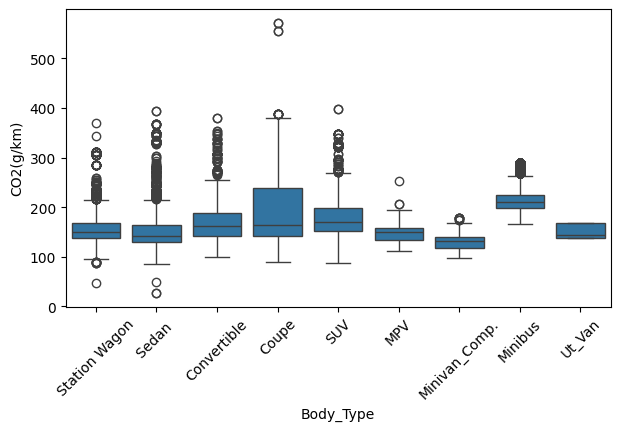

In [60]:

fig = sns.boxplot(x=df_filter_seg['Body_Type'], y=df_filter_seg['CO2(g/km)'])

plt.xticks(rotation=45)

plt.tight_layout()



fig.set_xticklabels(["Station Wagon", 'Sedan ', 'Convertible', 'Coupe', "SUV", "MPV", "Minivan_Comp.","Minibus","Ut_Van"])


In [61]:
from scipy.stats import f_oneway

groups = [
    group['CO2(g/km)'].dropna()
    for name, group in df_filter.groupby('Body_Type')
]

# Perform ANOVA
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 3832.5821432623975
p-value: 0.0


In [62]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_filter['CO2(g/km)'], groups=df_filter['Body_Type'], alpha=0.05)
print(tukey)

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
          BERLINE               BREAK  10.9492    0.0   8.6232  13.2753   True
          BERLINE           CABRIOLET  24.5952    0.0  20.6817  28.5088   True
          BERLINE          COMBISPACE   1.8308 0.7927  -1.5655   5.2272  False
          BERLINE               COUPE  47.4919    0.0  44.4544  50.5293   True
          BERLINE             MINIBUS  64.4797    0.0  63.0503  65.9091   True
          BERLINE           MINISPACE -19.9233    0.0 -27.7261 -12.1205   True
          BERLINE           MONOSPACE   0.4001    1.0  -8.1628   8.9631  False
          BERLINE   MONOSPACE COMPACT -18.6075    0.0  -22.559 -14.6561   True
          BERLINE TS TERRAINS/CHEMINS  31.6993    0.0  28.7774  34.6212   True
            BREAK           CABRIOLET   13.646    0.

In [63]:
df_filter['Body_Type'].isnull().sum()

np.int64(0)

In [64]:
df_filter['CO2(g/km)'].isnull().sum()

np.int64(0)